# Euro500 Equity Portfolio

This notebook constructs a quarterly rebalanced equity portfolio with 500 firms from the euro-area universe.

Core idea:
- Start from a broad equity universe in LSEG Workspace
- Apply transparent filters (country, listing, instrument type: ordinary/common/preference-style shares)
- Keep the top 500 by free-float market cap each quarter
- Build a quarterly rebalanced market portfolio and daily return series

Main outputs:
- `euro500.parquet` (quarterly constituents)
- `daily_returns_euro500_in_index.parquet` (firm-level daily returns while in index)
- `euro500_returns.parquet` (portfolio-level daily return series)



## 0. Setup

What this section does:
- Imports core libraries (`pandas`, `numpy`, plotting)
- Initializes the LSEG session
- Defines project paths and output locations
- Sets global parameters used in later steps

Note:
- Running this notebook requires an active local Workspace/LSEG connection.


In [129]:
# --- Imports & configuration ---
from pathlib import Path
import pandas as pd
import numpy as np
import lseg.data as ld
import time
import warnings

# --- Output paths (anpassen) ---
BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
(DATA_DIR := BASE_DIR / "intermediate").mkdir(parents=True, exist_ok=True)

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

warnings.filterwarnings(
    "ignore",
    message=r".*Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe"
)

# --- Shared helper functions (used across sections) ---
def normalize_ric(x: pd.Series) -> pd.Series:
    s = x.astype(str).str.strip().str.upper()
    s = s.str.replace(r"\^.*$", "", regex=True)
    s = s.replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    return s


def _best_col(df: pd.DataFrame, candidates: list[str]):
    cols = list(df.columns)
    lower = {str(c).lower(): c for c in cols}
    for c in candidates:
        if c in df.columns:
            return c
        cl = str(c).lower()
        if cl in lower:
            return lower[cl]
    return None


def _to_num(s):
    # Some LSEG pulls contain duplicate column labels; selection by label can return DataFrames.
    # Convert by position (iloc) to guarantee 1-D conversion before coalescing.
    if isinstance(s, pd.DataFrame):
        if s.shape[1] == 0:
            return pd.Series(np.nan, index=s.index, dtype="float64")
        cols = [pd.to_numeric(s.iloc[:, j], errors="coerce") for j in range(s.shape[1])]
        x = pd.concat(cols, axis=1)
        return x.bfill(axis=1).iloc[:, 0]

    if isinstance(s, pd.Series):
        return pd.to_numeric(s, errors="coerce")

    if isinstance(s, pd.Index):
        return pd.to_numeric(pd.Series(s.to_numpy()), errors="coerce")

    if isinstance(s, (list, tuple, set, np.ndarray)):
        vals = np.asarray(list(s) if isinstance(s, set) else s, dtype="object").ravel()
        return pd.to_numeric(pd.Series(vals), errors="coerce")

    return pd.to_numeric(pd.Series([s]), errors="coerce")


def _to_1d(s):
    """Ensure 1-D Series when a label-select returns duplicate columns."""
    if isinstance(s, pd.DataFrame):
        if s.shape[1] == 0:
            return pd.Series(pd.NA, index=s.index, dtype="object")
        return s.bfill(axis=1).iloc[:, 0]
    return s


def _pick_mcap_with_source(
    mcap_company: pd.Series,
    mcap_local: pd.Series,
    mcap_synth: pd.Series,
    synth_label: str = "price_x_shares",
) -> tuple[pd.Series, pd.Series]:
    mcap = mcap_company.combine_first(mcap_local).combine_first(mcap_synth)
    source = pd.Series(pd.NA, index=mcap.index, dtype="string")
    source = source.mask(mcap_company.notna(), "company_market_cap")
    source = source.mask(mcap_company.isna() & mcap_local.notna(), "market_cap_local_curn")
    source = source.mask(mcap_company.isna() & mcap_local.isna() & mcap_synth.notna(), synth_label)
    return mcap, source





## 1. Definition of the Investment Universe

This section defines the investable starting universe before any portfolio construction.

Design goal:
- A consistent and reproducible euro-area equity universe across the full sample.


### 1.1 Euro-Area Headquartered Firms

Baseline universe criteria:
- Publicly listed active equities
- Primary instruments
- Company headquarters located in euro-area countries

Why this matters:
- Keeps geographic exposure aligned with the research design
- Avoids mixing in non-euro-headquartered firms with different macro exposure

Instrument-type policy (default):
- Exclude `Depositary Receipts` (ADR/GDR/DR)
- Exclude `Stapled Securities`



In [130]:
import pandas as pd

EURO_ADOPTION = {
    # Founding members (book money from 1999-01-01)
    "AT": "1999-01-01",
    "BE": "1999-01-01",
    "FI": "1999-01-01",
    "FR": "1999-01-01",
    "DE": "1999-01-01",
    "IE": "1999-01-01",
    "IT": "1999-01-01",
    "LU": "1999-01-01",
    "NL": "1999-01-01",
    "PT": "1999-01-01",
    "ES": "1999-01-01",

    # Later entrants
    "GR": "2001-01-01",
    "SI": "2007-01-01",
    "CY": "2008-01-01",
    "MT": "2008-01-01",
    "SK": "2009-01-01",
    "EE": "2011-01-01",
    "LV": "2014-01-01",
    "LT": "2015-01-01",
    "HR": "2023-01-01",
}

EURO_ADOPTION_DT = {k: pd.Timestamp(v) for k, v in EURO_ADOPTION.items()}

# Irrevocable legacy currency conversion rates (legacy units per 1 EUR).
# Used to correct transition-day pulls where market cap can still arrive in legacy currency.
EURO_LEGACY_PER_EUR = {
    "AT": 13.7603,
    "BE": 40.3399,
    "FI": 5.94573,
    "FR": 6.55957,
    "DE": 1.95583,
    "IE": 0.787564,
    "IT": 1936.27,
    "LU": 40.3399,
    "NL": 2.20371,
    "PT": 200.482,
    "ES": 166.386,
    "GR": 340.75,
    "SI": 239.64,
    "CY": 0.585274,
    "MT": 0.4293,
    "SK": 30.1260,
    "EE": 15.6466,
    "LV": 0.702804,
    "LT": 3.45280,
    "HR": 7.53450,
}

def euro_hq_codes_for_quarter(formation_date: pd.Timestamp) -> list[str]:
    """
    Countries eligible for the euro area in the return period
    following the portfolio formation date.
    """
    eligibility_date = formation_date + pd.Timedelta(days=1)
    return sorted(
        c for c, d in EURO_ADOPTION_DT.items()
        if d <= eligibility_date
    )

# Broad common-equity filter (historical labels differ across years/venues)
COMMON_EQUITY_TYPE_PATTERNS = [
    "preference",
    "ordinary",
    "common",
    "registered",
    "voting",
    "aandeel",
    "aktion",
]

EXCLUDED_TYPE_PATTERNS = [
    "etf",
    "fund",
    "warrant",
    "certificate",
    "adr",
    "gdr",
    "unit",
    "right",
]

def is_common_equity_type(series: pd.Series) -> pd.Series:
    # Some instruments have missing InstrumentType in historical pulls.
    # Keep missing/blank types, and apply pattern filters where labels exist.
    x = series.astype("string").str.strip()
    missing = x.isna() | (x == "")
    s = x.str.lower().fillna("")

    keep = missing.copy()
    for pat in COMMON_EQUITY_TYPE_PATTERNS:
        keep = keep | s.str.contains(pat, na=False)
    for pat in EXCLUDED_TYPE_PATTERNS:
        keep = keep & ~s.str.contains(pat, na=False)
    return keep







### 1.1B Screen Builder

Here the LSEG Screener query is assembled.

The screen defines:
- Entity type and active status
- Region/country constraints
- Instrument-level restrictions

Output of this step:
- A reusable screen template used for each quarter in the sample loop.


In [131]:
def make_screen_euro_all_for_quarter(formation_date: pd.Timestamp) -> str:
    """
    SCREEN universe for euro-area headquartered ordinary shares only.
    """
    
    codes = euro_hq_codes_for_quarter(formation_date)
    codes = [c for c in codes if isinstance(c, str) and c.strip() != ""]

    if not codes:
        codes_str = '"ZZ"'
    else:
        codes_str = ",".join(f'"{c}"' for c in codes)

    screen = (
        "SCREEN("
        # Only active, public, primary listings
        "U(IN(Equity(active,public,primary))),"
        # HQ filter
        f"IN(TR.HQCountryCode,{codes_str}),"
        # Normalize currency
        "CURN=EUR"
        ")"
    )

    return screen

In [132]:
def pull_euro_equities_snapshot(formation_date: pd.Timestamp, max_retries: int = 3, sleep_s: float = 2.0):
    formation_date = pd.Timestamp(formation_date).normalize()
    date_iso = formation_date.strftime("%Y-%m-%d")

    # SCREEN universe (string)
    universe = [make_screen_euro_all_for_quarter(formation_date)]

    fields = [
        "TR.RIC",
        "TR.PrimaryRIC",
        "TR.ISIN",
        "TR.SEDOL",
        "TR.CommonName",
        "TR.HeadquartersCountry",
        "TR.HQCountryCode",
        "TR.TRBCEconomicSector",
        "TR.CompanyMarketCap",
        "TR.MarketCapLocalCurn",
        "TR.FreeFloat",
        "TR.FreeFloatPct",
        "TR.Volume",
        "TR.PriceClose",
        "TR.FirstTradeDate",
        "TR.IPODate",
        "TR.InstrumentType",
        "CF_CURR",
        "TR.IVCurrencyTypeCode",
    ]

    parameters = {
        "CURN": "EUR",
        "RH": "In",
        "CH": "Fd",
        "SDate": date_iso,
        "EDate": date_iso,
    }

    last_err = None

    for attempt in range(1, max_retries + 1):
        try:
            ld.open_session()
            try:
                df = ld.get_data(universe=universe, fields=fields, parameters=parameters)
            finally:
                ld.close_session()

            if df is None or df.empty:
                return pd.DataFrame()

            df = df.copy()

            # ---- IMPORTANT: strip empty identifiers (prevents downstream & some backend issues) ----
            for c in ["TR.RIC", "TR.PrimaryRIC", "TR.ISIN", "TR.SEDOL"]:
                if c in df.columns:
                    df[c] = df[c].astype(str).str.strip()
                    df.loc[df[c] == "", c] = pd.NA

            # IDs
            if "TR.PrimaryRIC" in df.columns:
                df["RIC_current"] = df["TR.PrimaryRIC"].fillna(df.get("TR.RIC"))
            else:
                df["RIC_current"] = df.get("TR.RIC")

            # firm_id: stable instrument/entity proxy with explicit id type prefix
            df["firm_id"] = pd.Series(pd.NA, index=df.index, dtype="string")
            for id_type, col in [
                ("ISIN", "TR.ISIN"),
                ("RIC", "RIC_current"),
                ("RIC", "TR.RIC"),
                ("SEDOL", "TR.SEDOL"),
            ]:
                if col in df.columns:
                    v = df[col].astype("string").str.strip()
                    v = v.where(v.notna() & (v != ""), pd.NA)
                    df["firm_id"] = df["firm_id"].fillna(id_type + ":" + v)

            # Rename columns
            df = df.rename(columns={
                "TR.CommonName": "CompanyName",
                "TR.HeadquartersCountry": "HQCountry",
                "TR.HQCountryCode": "HQCountryCode",
                "TR.TRBCEconomicSector": "Sector",
                "TR.CompanyMarketCap": "CompanyMarketCap_EUR",
                "TR.MarketCapLocalCurn": "MarketCap_EUR",
                "TR.ISIN": "ISIN",
                "TR.SEDOL": "SEDOL",
                "TR.FreeFloat": "FreeFloat",
                "TR.FreeFloatPct": "FreeFloatPct",
                "TR.Volume": "Volume",
                "TR.PriceClose": "PriceClose",
                "TR.FirstTradeDate": "FirstTradeDate",
                "TR.IPODate": "IPODate",
                "TR.InstrumentType": "InstrumentType",
                "CF_CURR": "Currency",
                "TR.IVCurrencyTypeCode": "IVCurrencyTypeCode",
            })

            # Numeric coercion
            for c in ["CompanyMarketCap_EUR", "MarketCap_EUR", "FreeFloat", "FreeFloatPct", "Volume", "PriceClose"]:
                if c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="coerce")

            if "FirstTradeDate" in df.columns:
                df["FirstTradeDate"] = pd.to_datetime(df["FirstTradeDate"], errors="coerce").dt.normalize()
            if "IPODate" in df.columns:
                df["IPODate"] = pd.to_datetime(df["IPODate"], errors="coerce").dt.normalize()

            if "Currency" not in df.columns:
                df["Currency"] = pd.NA

            cf = df["Currency"].astype("string").str.strip()
            cf = cf.where(cf.notna() & (cf != ""), pd.NA)

            if "IVCurrencyTypeCode" in df.columns:
                iv = df["IVCurrencyTypeCode"].astype("string").str.strip()
                iv = iv.where(iv.notna() & (iv != ""), pd.NA)
                df["Currency"] = cf.fillna(iv)
                df = df.drop(columns=["IVCurrencyTypeCode"])
            else:
                df["Currency"] = cf

            return df

        except Exception as e:
            last_err = e
            time.sleep(sleep_s * attempt)





In [133]:
for d in [
    pd.Timestamp("1998-12-31"),
    pd.Timestamp("2001-03-31"),
    pd.Timestamp("2008-03-31"),
    pd.Timestamp("2015-03-31"),
    pd.Timestamp("2025-03-31"),
]:
    print(d.date(), euro_hq_codes_for_quarter(d))


1998-12-31 ['AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'IE', 'IT', 'LU', 'NL', 'PT']
2001-03-31 ['AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LU', 'NL', 'PT']
2008-03-31 ['AT', 'BE', 'CY', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LU', 'MT', 'NL', 'PT', 'SI']
2015-03-31 ['AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']
2025-03-31 ['AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']


### 1.2 Sample Period

Sample definition:
- Quarterly snapshots from 1999Q1 to 2025Q4

Implementation logic:
- For each quarter-end date, the same screen is executed
- This produces a time-consistent panel of constituents for ranking and selection


In [134]:
# Quarter schedule: formation_date (last business day of previous quarter)
# and effective_date (first business day of current quarter)
START_QUARTER = "1999Q1"
TODAY = pd.Timestamp.today().normalize()
LAST_COMPLETED_Q = TODAY.to_period("Q") - 1

quarters = pd.period_range(START_QUARTER, LAST_COMPLETED_Q, freq="Q")
rebalance_calendar = pd.DataFrame({"quarter": quarters.astype(str)})
rebalance_calendar["effective_date"] = quarters.to_timestamp(how="start")
rebalance_calendar["effective_date"] = pd.to_datetime(rebalance_calendar["effective_date"]) + pd.offsets.BDay(0)
rebalance_calendar["formation_date"] = rebalance_calendar["effective_date"] - pd.offsets.BDay(1)

print("Today:", TODAY.date())
print("Last completed quarter:", str(LAST_COMPLETED_Q))
print("First rows:")
display(rebalance_calendar.head())
print("Last rows:")
display(rebalance_calendar.tail())


Today: 2026-02-22
Last completed quarter: 2025Q4
First rows:


,quarter,effective_date,formation_date
0,1999Q1,1999-01-01,1998-12-31
1,1999Q2,1999-04-01,1999-03-31
2,1999Q3,1999-07-01,1999-06-30
3,1999Q4,1999-10-01,1999-09-30
4,2000Q1,2000-01-03,1999-12-31


Last rows:


,quarter,effective_date,formation_date
103,2024Q4,2024-10-01,2024-09-30
104,2025Q1,2025-01-01,2024-12-31
105,2025Q2,2025-04-01,2025-03-31
106,2025Q3,2025-07-01,2025-06-30
107,2025Q4,2025-10-01,2025-09-30


## 2. Workspace Screener

This block executes the screen and retrieves the required fields from LSEG.

Typical fields include:
- Identifiers (RIC, ISIN, company keys)
- Company metadata
- Free-float market capitalization and related ranking variables


In [135]:
# ------------------------------------------------------------
# Cache: quarterly snapshots
# ------------------------------------------------------------
CACHE_DIR = DATA_DIR / "euro_snap_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SNAP_CACHE_SCHEMA_VERSION = "v7"

def _cache_path(formation_date: pd.Timestamp) -> Path:
    d = pd.Timestamp(formation_date).strftime("%Y-%m-%d")
    return CACHE_DIR / f"euro_snapshot_{SNAP_CACHE_SCHEMA_VERSION}_{d}.parquet"

def _legacy_cache_path(formation_date: pd.Timestamp) -> Path:
    d = pd.Timestamp(formation_date).strftime("%Y-%m-%d")
    return CACHE_DIR / f"euro_snapshot_{d}.parquet"


# ------------------------------------------------------------
# Helpers: clean universes + robust retry wrapper
# ------------------------------------------------------------
def _clean_universe_list(x):
    """Drop NA/empty/whitespace-only and ensure unique strings."""
    if x is None:
        return []

    if isinstance(x, pd.DataFrame):
        vals = x.to_numpy().ravel()
    elif isinstance(x, (pd.Series, pd.Index)):
        vals = x.to_numpy()
    elif isinstance(x, (list, tuple, set, np.ndarray)):
        vals = np.asarray(list(x), dtype="object").ravel()
    else:
        vals = np.asarray([x], dtype="object")

    s = pd.Series(vals, dtype="object").dropna().astype(str).str.strip()
    s = s[s != ""]
    return s.drop_duplicates().tolist()


def _coalesce_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse duplicate column labels into a single best-effort column."""
    out = pd.DataFrame(index=df.index)
    for c in dict.fromkeys(map(str, df.columns)):
        v = df.loc[:, c]
        if isinstance(v, pd.DataFrame):
            num = _to_num(v)
            txt = v.astype("string").bfill(axis=1).iloc[:, 0]
            out[c] = num.where(num.notna(), txt)
        else:
            out[c] = v
    return out

def _safe_get_data(universe, fields, parameters, max_retries=3, base_sleep=2.0):
    """Robust ld.get_data with cleaned universe + retry."""
    universe = _clean_universe_list(universe)
    if not universe:
        return pd.DataFrame()

    last = None
    for r in range(1, max_retries + 1):
        try:
            df = ld.get_data(universe=universe, fields=fields, parameters=parameters)
            if df is None:
                return pd.DataFrame()
            return df
        except Exception as e:
            last = e
            time.sleep(base_sleep * r)
    raise last


def _ensure_firm_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "firm_id" not in out.columns:
        fid = pd.Series(pd.NA, index=out.index, dtype="string")

        if "ISIN" in out.columns:
            v = out["ISIN"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("ISIN:" + v)

        if "RIC_current" in out.columns:
            v = out["RIC_current"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("RIC:" + v)

        if "RIC" in out.columns:
            v = out["RIC"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("RIC:" + v)

        if "SEDOL" in out.columns:
            v = out["SEDOL"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            fid = fid.fillna("SEDOL:" + v)

        out["firm_id"] = fid

    out["firm_id"] = out["firm_id"].astype("string").str.strip()
    out.loc[(out["firm_id"] == "") | (out["firm_id"].str.lower() == "nan"), "firm_id"] = pd.NA

    return out


def _mcap_coverage(df: pd.DataFrame) -> float:
    if df is None or len(df) == 0 or "mcap_eur" not in df.columns:
        return 0.0
    return float(df["mcap_eur"].notna().mean())


def _apply_euro_entry_fx_guard(out: pd.DataFrame, formation_date: pd.Timestamp) -> pd.DataFrame:
    """
    Selective transition-day FX fix.

    We only convert when both conditions hold:
    1) The row is on a euro-adoption transition day for its HQ country.
    2) A reference market cap (prefer price*shares, fallback instrument mcap) indicates
       the current mcap is still in legacy-currency units (ratio close to legacy fix rate).
    """
    if out is None or out.empty or "mcap_eur" not in out.columns or "hq_code" not in out.columns:
        return out

    out = out.copy()
    formation_date = pd.Timestamp(formation_date).normalize()
    next_day = formation_date + pd.Timedelta(days=1)

    hq = out["hq_code"].astype("string").str.strip().str.upper()
    rates = hq.map(EURO_LEGACY_PER_EUR).astype("float64")
    adoption = pd.to_datetime(hq.map(EURO_ADOPTION_DT), errors="coerce")

    if "mcap_source" not in out.columns:
        out["mcap_source"] = pd.Series(pd.NA, index=out.index, dtype="string")

    src = out["mcap_source"].astype("string")
    src_lower = src.str.lower()
    source_ok = src_lower.isin({"company_market_cap", "market_cap_local_curn", "legacy_cache_unknown"})

    transition_mask = adoption.notna() & (formation_date < adoption) & (adoption <= next_day)
    mcap = _to_num(out["mcap_eur"])

    # Reference mcap for plausibility: prefer synthetic (price*shares), fallback instrument mcap.
    if "_mcap_ref_fx" in out.columns:
        ref = _to_num(out["_mcap_ref_fx"])
    else:
        ref = pd.Series(np.nan, index=out.index, dtype="float64")

    ratio = mcap / ref
    ratio_over_rate = ratio / rates

    has_ref = ref.notna() & (ref > 0)
    has_rate = rates.notna() & (rates > 0)

    # Plausibility: mcap/ref is close to legacy fix-rate, and clearly not near 1x.
    plausibly_legacy_units = (
        has_ref
        & has_rate
        & ratio.notna()
        & ratio_over_rate.between(0.67, 1.50)
        & ((ratio >= 1.50) | (ratio <= 0.67))
    )

    fix_mask = transition_mask & source_ok & mcap.notna() & plausibly_legacy_units

    if not bool(fix_mask.any()):
        return out

    out.loc[fix_mask, "mcap_eur"] = mcap.loc[fix_mask] / rates.loc[fix_mask]

    src_fixed = src.copy()
    src_fixed = src_fixed.mask(fix_mask & src_lower.eq("company_market_cap"), "company_market_cap_fx_fixed")
    src_fixed = src_fixed.mask(fix_mask & src_lower.eq("market_cap_local_curn"), "market_cap_local_curn_fx_fixed")
    src_fixed = src_fixed.mask(fix_mask & src_lower.eq("legacy_cache_unknown"), "legacy_cache_unknown_fx_fixed")
    out["mcap_source"] = src_fixed

    return out

def _augment_missing_with_backfill_window(
    out: pd.DataFrame,
    formation_date: pd.Timestamp,
    max_retries: int = 3,
    sleep_s: float = 2.0,
    offsets_days: tuple[int, ...] = tuple(range(1, 21)),
) -> pd.DataFrame:
    """
    Improve early-history coverage (e.g. 1998-12-31) by filling missing fields
    from prior business days for the same RIC.
    """
    if out is None or out.empty:
        return out

    out = out.copy()
    fill_cols = ["mcap_eur", "PriceClose", "FreeFloatPct", "FreeFloat", "Volume"]
    for c in fill_cols:
        if c not in out.columns:
            out[c] = np.nan

    backfill_fields = [
        "TR.RIC",
        "TR.CompanyMarketCap",
        "TR.MarketCapLocalCurn",
        "TR.PriceClose",
        "TR.FreeFloatPct",
        "TR.FreeFloat",
        "TR.Volume",
        "TR.SharesOutstanding",
        "TR.CompanySharesOutstanding",
    ]

    for off in offsets_days:
        missing_mask = out[fill_cols].isna().any(axis=1)
        miss_rics = _clean_universe_list(out.loc[missing_mask, "RIC"].tolist())
        if not miss_rics:
            break

        d = (pd.Timestamp(formation_date) - pd.Timedelta(days=off)).strftime("%Y-%m-%d")
        params = {"CURN": "EUR", "RH": "In", "CH": "Fd", "SDate": d, "EDate": d}

        try:
            ld.open_session()
            try:
                raw = _safe_get_data(
                    universe=miss_rics,
                    fields=backfill_fields,
                    parameters=params,
                    max_retries=max_retries,
                    base_sleep=sleep_s,
                )
            finally:
                ld.close_session()
        except Exception:
            continue

        if raw is None or len(raw) == 0:
            continue

        col_ric = _best_col(raw, ["RIC", "TR.RIC", "Instrument"])
        if col_ric is None:
            continue

        col_company_mcap = _best_col(raw, ["Company Market Cap", "TR.CompanyMarketCap", "TR.COMPANYMARKETCAP"])
        col_instr_mcap = _best_col(raw, ["Market Cap", "TR.MarketCapLocalCurn", "TR.MARKETCAPLOCALCURN"])
        col_px = _best_col(raw, ["TR.PriceClose", "Price Close", "Close Price", "TR.PRICECLOSE", "TR.CLOSEPRICE"])
        col_ffpct = _best_col(raw, ["TR.FreeFloatPct", "Free Float Percent", "TR.FREEFLOATPCT"])
        col_ff = _best_col(raw, ["TR.FreeFloat", "Free Float", "TR.FREEFLOAT"])
        col_vol = _best_col(raw, ["TR.Volume", "Volume", "TR.VOLUME"])
        col_sh1 = _best_col(raw, ["TR.SharesOutstanding", "Shares Outstanding", "TR.SHARESOUTSTANDING"])
        col_sh2 = _best_col(raw, ["TR.CompanySharesOutstanding", "TR.COMPANYSHARESOUTSTANDING"])

        upd = pd.DataFrame({"RIC": _to_1d(raw[col_ric]).astype(str).str.strip()})
        upd = upd[upd["RIC"] != ""].copy()

        mcap_company = _to_num(raw[col_company_mcap]) if col_company_mcap else pd.Series(np.nan, index=raw.index, dtype="float64")
        mcap_instr = _to_num(raw[col_instr_mcap]) if col_instr_mcap else pd.Series(np.nan, index=raw.index, dtype="float64")
        px = _to_num(raw[col_px]) if col_px else pd.Series(np.nan, index=raw.index, dtype="float64")
        sh1 = _to_num(raw[col_sh1]) if col_sh1 else pd.Series(np.nan, index=raw.index, dtype="float64")
        sh2 = _to_num(raw[col_sh2]) if col_sh2 else pd.Series(np.nan, index=raw.index, dtype="float64")
        shares = sh1.combine_first(sh2)
        mcap_synth = px * shares

        mcap_fill, mcap_source_fill = _pick_mcap_with_source(
            mcap_company=mcap_company,
            mcap_local=mcap_instr,
            mcap_synth=mcap_synth,
            synth_label="backfill_price_x_shares",
        )
        upd["mcap_eur"] = mcap_fill
        upd["mcap_source_bf"] = mcap_source_fill
        upd["PriceClose"] = px
        upd["FreeFloatPct"] = _to_num(raw[col_ffpct]) if col_ffpct else np.nan
        upd["FreeFloat"] = _to_num(raw[col_ff]) if col_ff else np.nan
        upd["Volume"] = _to_num(raw[col_vol]) if col_vol else np.nan

        upd = upd.drop_duplicates(subset=["RIC"], keep="first")
        out = out.merge(upd, on="RIC", how="left", suffixes=("", "_bf"))

        for c in fill_cols:
            bf = f"{c}_bf"
            if bf in out.columns:
                before_missing = _to_num(out[c]).isna()
                out[c] = _to_num(out[c]).fillna(_to_num(out[bf]))
                if c == "mcap_eur" and "mcap_source_bf" in out.columns:
                    filled_now = before_missing & _to_num(out[c]).notna()
                    if "mcap_source" not in out.columns:
                        out["mcap_source"] = pd.NA
                    out.loc[filled_now, "mcap_source"] = out.loc[filled_now, "mcap_source_bf"]
                out = out.drop(columns=[bf])

        if "mcap_source_bf" in out.columns:
            out = out.drop(columns=["mcap_source_bf"])

    return out


# ------------------------------------------------------------
# Main: pull quarterly Euro equities snapshot (safe + cached)
# ------------------------------------------------------------
def pull_euro_equities_snapshot_safe(
    formation_date,
    max_retries: int = 3,
    sleep_s: float = 2.0,
    min_cached_mcap_coverage: float = 0.60,
    min_target_mcap_coverage: float = 0.85,
    enable_backfill: bool = False,
) -> pd.DataFrame:
    """
    Safe wrapper: cache + retry + robust market-cap fallback.
    """
    formation_date = pd.Timestamp(formation_date).normalize()
    date_iso = formation_date.strftime("%Y-%m-%d")

    p = _cache_path(formation_date)
    p_legacy = _legacy_cache_path(formation_date)
    if p.exists() or p_legacy.exists():
        read_path = p if p.exists() else p_legacy
        cached = pd.read_parquet(read_path)

        # Legacy cache files can contain duplicate labels (e.g. multiple mcap_eur columns).
        # Coalesce duplicates into one column to avoid 2-D inputs in downstream ops.
        cached = _coalesce_duplicate_columns(cached)

        cached = _ensure_firm_id(cached)
        if "mcap_source" not in cached.columns:
            cached["mcap_source"] = pd.Series(pd.NA, index=cached.index, dtype="string")
            cached.loc[_to_num(cached.get("mcap_eur")).notna(), "mcap_source"] = "legacy_cache_unknown"

        if "Currency" not in cached.columns:
            cached["Currency"] = cached["CF_CURR"] if "CF_CURR" in cached.columns else pd.NA

        cf_cached = cached["Currency"].astype("string").str.strip()
        cf_cached = cf_cached.where(cf_cached.notna() & (cf_cached != ""), pd.NA)
        if "IVCurrencyTypeCode" in cached.columns:
            iv_cached = cached["IVCurrencyTypeCode"].astype("string").str.strip()
            iv_cached = iv_cached.where(iv_cached.notna() & (iv_cached != ""), pd.NA)
            cached["Currency"] = cf_cached.fillna(iv_cached)
            cached = cached.drop(columns=["IVCurrencyTypeCode"])
        else:
            cached["Currency"] = cf_cached

        if "first_trade_date" not in cached.columns:
            cached["first_trade_date"] = pd.NaT
        cached["first_trade_date"] = pd.to_datetime(cached["first_trade_date"], errors="coerce").dt.normalize()

        if "ipo_date" not in cached.columns:
            cached["ipo_date"] = pd.NaT
        cached["ipo_date"] = pd.to_datetime(cached["ipo_date"], errors="coerce").dt.normalize()

        cached["start_date"] = cached["first_trade_date"].where(cached["first_trade_date"].notna(), cached["ipo_date"])

        cached = _apply_euro_entry_fx_guard(cached, formation_date=formation_date)
        if "CF_CURR" in cached.columns:
            cached = cached.drop(columns=["CF_CURR"])
        if "_mcap_ref_fx" in cached.columns:
            cached = cached.drop(columns=["_mcap_ref_fx"])
        cached.to_parquet(p, index=False)
        return cached

    universe = [make_screen_euro_all_for_quarter(formation_date)]

    base = [
        "TR.RIC", "TR.PrimaryRIC", "TR.ISIN", "TR.SEDOL",
        "TR.CommonName", "TR.HeadquartersCountry", "TR.HQCountryCode",
        "TR.TRBCEconSectorCode", "TR.TRBCEconomicSector",
        "TR.FreeFloat", "TR.FreeFloatPct", "TR.Volume", "TR.PriceClose", "TR.FirstTradeDate", "TR.IPODate", "TR.InstrumentType", "CF_CURR", "TR.IVCurrencyTypeCode",
        "TR.SharesOutstanding", "TR.CompanySharesOutstanding",
    ]

    field_sets = [
        base + ["TR.CompanyMarketCap", "TR.MarketCapLocalCurn"],
        base + ["TR.MarketCapLocalCurn"],
        base + ["TR.CompanyMarketCap"],
    ]

    params = {"CURN": "EUR", "RH": "In", "CH": "Fd", "SDate": date_iso, "EDate": date_iso}

    last_err = None

    for fields in field_sets:
        for attempt in range(1, max_retries + 1):
            try:
                ld.open_session()
                try:
                    df = _safe_get_data(
                        universe=universe,
                        fields=fields,
                        parameters=params,
                        max_retries=max_retries,
                        base_sleep=sleep_s,
                    ).copy()
                    df = _coalesce_duplicate_columns(df)
                finally:
                    ld.close_session()

                if df is None or len(df) == 0:
                    out = pd.DataFrame(columns=[
                        "RIC", "name", "hq_country", "hq_code",
                        "trbc_sector_code", "trbc_sector", "mcap_eur", "mcap_source",
                        "RIC_current", "ISIN", "SEDOL", "firm_id",
                        "FreeFloat", "FreeFloatPct", "Volume", "PriceClose", "first_trade_date", "ipo_date", "start_date", "InstrumentType", "Currency",
                    ])
                    out.to_parquet(p, index=False)
                    return out

                col_ric = _best_col(df, ["RIC", "TR.RIC", "Instrument"])
                col_name = _best_col(df, ["Company Common Name", "TR.CommonName", "TR.COMMONNAME"])
                col_hq_country = _best_col(df, ["Country of Headquarters", "TR.HeadquartersCountry", "TR.HEADQUARTERSCOUNTRY"])
                col_hq_code = _best_col(df, ["Country ISO Code of Headquarters", "TR.HQCountryCode", "TR.HQCOUNTRYCODE"])
                col_trbc_code = _best_col(df, ["TRBC Economic Sector Code", "TR.TRBCEconSectorCode", "TR.TRBCECONSECTORCODE"])
                col_trbc_name = _best_col(df, ["TRBC Economic Sector Name", "TR.TRBCEconomicSector", "TR.TRBCECONOMICSECTOR"])

                col_company_mcap = _best_col(df, ["Company Market Cap", "TR.CompanyMarketCap", "TR.COMPANYMARKETCAP"])
                col_instr_mcap = _best_col(df, ["Market Cap", "TR.MarketCapLocalCurn", "TR.MARKETCAPLOCALCURN"])

                col_primary = _best_col(df, ["TR.PrimaryRIC", "TR.PRIMARYRIC", "Primary Issue RIC", "Primary RIC"])
                col_isin = _best_col(df, ["TR.ISIN", "TR.ISINCode", "ISIN", "TR.ISINCODE"])
                col_sedol = _best_col(df, ["TR.SEDOL", "SEDOL", "TR.SEDOLCode", "TR.SEDOLCODE"])
                col_ftd = _best_col(df, ["First Trade Date", "TR.FirstTradeDate", "TR.FIRSTTRADEDATE"])
                col_ipo = _best_col(df, ["IPO Date", "TR.IPODate", "TR.IPODATE"])

                col_ff = _best_col(df, ["TR.FreeFloat", "Free Float", "TR.FREEFLOAT"])
                col_ffpct = _best_col(df, ["TR.FreeFloatPct", "Free Float (Percent)", "Free Float Percent", "TR.FREEFLOATPCT"])
                col_vol = _best_col(df, ["TR.Volume", "Volume", "TR.VOLUME"])
                col_px = _best_col(df, ["TR.PriceClose", "Price Close", "Close Price", "TR.PRICECLOSE", "TR.CLOSEPRICE"])
                col_type = _best_col(df, ["TR.InstrumentType", "Instrument Type", "TR.INSTRUMENTTYPE"])

                col_sh1 = _best_col(df, ["TR.SharesOutstanding", "Shares Outstanding", "TR.SHARESOUTSTANDING"])
                col_cf_curr = _best_col(df, ["CF_CURR", "Currency"])
                col_iv_curr = _best_col(df, ["TR.IVCurrencyTypeCode", "IV Currency Type Code", "TR.IVCURRENCYTYPECODE"])
                col_sh2 = _best_col(df, ["TR.CompanySharesOutstanding", "TR.COMPANYSHARESOUTSTANDING"])

                if col_ric is None:
                    raise KeyError(f"No RIC column. Got: {list(df.columns)}")

                # Keep going even if explicit market-cap fields are absent in this pull;
                # fallback can still compute mcap from price x shares.

                mcap_company = _to_num(df[col_company_mcap]) if col_company_mcap else pd.Series(np.nan, index=df.index, dtype="float64")
                mcap_instr = _to_num(df[col_instr_mcap]) if col_instr_mcap else pd.Series(np.nan, index=df.index, dtype="float64")

                px = _to_num(df[col_px]) if col_px else pd.Series(np.nan, index=df.index, dtype="float64")
                sh1 = _to_num(df[col_sh1]) if col_sh1 else pd.Series(np.nan, index=df.index, dtype="float64")
                sh2 = _to_num(df[col_sh2]) if col_sh2 else pd.Series(np.nan, index=df.index, dtype="float64")
                shares = sh1.combine_first(sh2)

                mcap_synth = px * shares

                mcap_eur, mcap_source = _pick_mcap_with_source(
                    mcap_company=mcap_company,
                    mcap_local=mcap_instr,
                    mcap_synth=mcap_synth,
                )

                out = pd.DataFrame({
                    "RIC": _to_1d(df[col_ric]),
                    "name": _to_1d(df[col_name]) if col_name else pd.NA,
                    "hq_country": _to_1d(df[col_hq_country]) if col_hq_country else pd.NA,
                    "hq_code": _to_1d(df[col_hq_code]) if col_hq_code else pd.NA,
                    "trbc_sector_code": _to_1d(df[col_trbc_code]) if col_trbc_code else pd.NA,
                    "trbc_sector": _to_1d(df[col_trbc_name]) if col_trbc_name else pd.NA,
                    "mcap_eur": mcap_eur,
                    "mcap_source": mcap_source,
                    "_mcap_ref_fx": mcap_synth.where(mcap_synth > 0).combine_first(mcap_instr.where(mcap_instr > 0)),

                                        "RIC_current": _to_1d(df[col_primary]) if col_primary else _to_1d(df[col_ric]),
                    "ISIN": _to_1d(df[col_isin]) if col_isin else pd.NA,
                    "SEDOL": _to_1d(df[col_sedol]) if col_sedol else pd.NA,
                    "first_trade_date": pd.to_datetime(_to_1d(df[col_ftd]), errors="coerce").dt.normalize() if col_ftd else pd.NaT,
                    "ipo_date": pd.to_datetime(_to_1d(df[col_ipo]), errors="coerce").dt.normalize() if col_ipo else pd.NaT,

                    "FreeFloat": _to_1d(df[col_ff]) if col_ff else pd.NA,
                    "FreeFloatPct": _to_1d(df[col_ffpct]) if col_ffpct else pd.NA,
                    "Volume": _to_1d(df[col_vol]) if col_vol else pd.NA,
                    "PriceClose": px,
                    "InstrumentType": _to_1d(df[col_type]) if col_type else pd.NA,
                    "Currency": _to_1d(df[col_cf_curr]) if col_cf_curr else pd.NA,
                    "IVCurrencyTypeCode": _to_1d(df[col_iv_curr]) if col_iv_curr else pd.NA,
                })

                for idc in ["RIC", "RIC_current", "ISIN", "SEDOL"]:
                    out[idc] = out[idc].astype(str).str.strip()
                    out.loc[out[idc] == "", idc] = pd.NA

                out["firm_id"] = pd.Series(pd.NA, index=out.index, dtype="string")
                for id_type, col in [("ISIN", "ISIN"), ("RIC", "RIC_current"), ("RIC", "RIC"), ("SEDOL", "SEDOL")]:
                    if col in out.columns:
                        v = out[col].astype("string").str.strip()
                        v = v.where(v.notna() & (v != ""), pd.NA)
                        out["firm_id"] = out["firm_id"].fillna(id_type + ":" + v)

                for c in ["mcap_eur", "FreeFloat", "FreeFloatPct", "Volume", "PriceClose"]:
                    out[c] = _to_num(out[c])

                if "Currency" not in out.columns:
                    out["Currency"] = pd.NA

                cf_out = out["Currency"].astype("string").str.strip()
                cf_out = cf_out.where(cf_out.notna() & (cf_out != ""), pd.NA)

                if "IVCurrencyTypeCode" in out.columns:
                    iv_out = out["IVCurrencyTypeCode"].astype("string").str.strip()
                    iv_out = iv_out.where(iv_out.notna() & (iv_out != ""), pd.NA)
                    out["Currency"] = cf_out.fillna(iv_out)
                    out = out.drop(columns=["IVCurrencyTypeCode"])
                else:
                    out["Currency"] = cf_out

                out["first_trade_date"] = pd.to_datetime(out.get("first_trade_date"), errors="coerce").dt.normalize()
                out["ipo_date"] = pd.to_datetime(out.get("ipo_date"), errors="coerce").dt.normalize()
                out["start_date"] = out["first_trade_date"].where(out["first_trade_date"].notna(), out["ipo_date"])

                out = out.dropna(subset=["RIC"]).copy()

                cov_before = _mcap_coverage(out)
                has_missing_mcap = bool(out["mcap_eur"].isna().any()) if "mcap_eur" in out.columns else True
                if enable_backfill and has_missing_mcap:
                    out = _augment_missing_with_backfill_window(
                        out=out,
                        formation_date=formation_date,
                        max_retries=max_retries,
                        sleep_s=sleep_s,
                    )
                    cov_after = _mcap_coverage(out)
                    print(f"  mcap coverage improved: {cov_before:.1%} -> {cov_after:.1%}")

                out = _apply_euro_entry_fx_guard(out, formation_date=formation_date)
                out = _ensure_firm_id(out)
                if "CF_CURR" in out.columns:
                    out = out.drop(columns=["CF_CURR"])
                if "_mcap_ref_fx" in out.columns:
                    out = out.drop(columns=["_mcap_ref_fx"])
                out.to_parquet(p, index=False)
                return out

            except Exception as e:
                last_err = e
                time.sleep(sleep_s * attempt)

    raise last_err








### 2.2 Quarterly Loop: Pull All Equities per Date

For each quarter-end in the sample:
1. Run the screen in Workspace
2. Pull all matching equities with requested fields
3. Append date-stamped results into one panel

Result:
- A raw quarterly universe panel before top-500 selection.

Pipeline notation in code:
- `screen_raw` = Step1 SCREEN output
- `screen_filtered` = after instrument/sector filters
- `preselected1500` = hard mcap preselection before top-500
- `final500` = quarterly EURO500 constituents



In [136]:
def build_quarterly_euro_panel_safe(
    rebalance_calendar: pd.DataFrame,
    preselect_top_n: int = 1500,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    import traceback

    out = []
    failures = []

    for row in rebalance_calendar.itertuples(index=False):
        quarter = row.quarter
        formation_date = pd.Timestamp(row.formation_date).normalize()
        effective_date = pd.Timestamp(row.effective_date).normalize()
        date_iso = formation_date.strftime("%Y-%m-%d")

        print(
            f"Quarter {quarter}: formation={formation_date.date()} -> effective={effective_date.date()}"
        )

        try:
            screen_raw = pull_euro_equities_snapshot_safe(formation_date, enable_backfill=False).copy()
            snap = _coalesce_duplicate_columns(screen_raw)

            # Keep legacy 'date' for downstream compatibility and add explicit dates.
            snap.insert(0, "date", formation_date)
            snap.insert(1, "formation_date", formation_date)
            snap.insert(2, "effective_date", effective_date)
            snap.insert(3, "quarter", quarter)

            if "first_trade_date" not in snap.columns:
                snap["first_trade_date"] = pd.NaT
            if "ipo_date" not in snap.columns:
                snap["ipo_date"] = pd.NaT

            snap["first_trade_date"] = pd.to_datetime(snap["first_trade_date"], errors="coerce").dt.normalize()
            snap["ipo_date"] = pd.to_datetime(snap["ipo_date"], errors="coerce").dt.normalize()

            # Default: FirstTradeDate first, then IPODate fallback.
            snap["start_date"] = snap["first_trade_date"].where(snap["first_trade_date"].notna(), snap["ipo_date"])

            # Data-quality guard: if FirstTradeDate is implausibly after quarter start but IPODate is before,
            # prefer IPODate (important for early-history feeds such as IT names with clustered FirstTradeDate).
            ftd_implausible = (
                snap["first_trade_date"].notna()
                & snap["ipo_date"].notna()
                & (snap["first_trade_date"] >= effective_date)
                & (snap["ipo_date"] < effective_date)
            )
            if bool(ftd_implausible.any()):
                n_fix = int(ftd_implausible.sum())
                snap.loc[ftd_implausible, "start_date"] = snap.loc[ftd_implausible, "ipo_date"]
                print(f"  start_date fallback: replaced FirstTradeDate with IPODate for {n_fix} rows")

            start_viol = snap["start_date"].notna() & (snap["start_date"] >= effective_date)
            if bool(start_viol.any()):
                n_viol = int(start_viol.sum())
                snap = snap.loc[~start_viol].copy()
                print(f"  start_date filter: dropped {n_viol} rows with start_date >= quarter_start ({effective_date.date()})")

            if "Currency" not in snap.columns:
                if "CF_CURR" in snap.columns:
                    snap["Currency"] = snap["CF_CURR"]
                else:
                    raise KeyError("Currency column missing in snapshot. Run pull cells with currency fields enabled.")

            snap["Currency"] = snap["Currency"].astype("string").str.strip().str.upper()
            non_eur = snap["Currency"].ne("EUR") | snap["Currency"].isna()
            if bool(non_eur.any()):
                n_non_eur = int(non_eur.sum())
                snap = snap.loc[~non_eur].copy()
                print(f"  currency filter: dropped {n_non_eur} rows with Currency != EUR")

            if "InstrumentType" in snap.columns:
                snap["InstrumentType"] = snap["InstrumentType"].astype(str).str.strip()
                snap = snap[is_common_equity_type(snap["InstrumentType"])].copy()

            # Prefer observations with non-missing and higher market cap before dedupe.
            if "mcap_eur" in snap.columns:
                snap["_has_mcap"] = snap["mcap_eur"].notna().astype(int)
                snap = snap.sort_values(["_has_mcap", "mcap_eur", "RIC"], ascending=[False, False, True]).drop(columns=["_has_mcap"])

            if "firm_id" in snap.columns:
                snap["_dedupe_key"] = snap["firm_id"].where(snap["firm_id"].notna(), snap["RIC"])
                snap = snap.drop_duplicates(subset=["date", "_dedupe_key"], keep="first").drop(columns=["_dedupe_key"])
            else:
                snap = snap.drop_duplicates(subset=["date", "RIC"], keep="first")


            # Step labels in pipeline:
            # screen_raw -> screen_filtered -> preselected1500 -> final500 (later section)
            # Optional universe cap before downstream work: keep largest names only.
            if preselect_top_n is not None and preselect_top_n > 0 and "mcap_eur" in snap.columns:
                before_n = len(snap)
                snap = (
                    snap.dropna(subset=["mcap_eur"])
                    .sort_values(["mcap_eur", "RIC"], ascending=[False, True])
                    .head(preselect_top_n)
                    .copy()
                )
                print(f"  preselect_top_n={preselect_top_n}: {before_n} -> {len(snap)}")

            mcap_cov = float(snap["mcap_eur"].notna().mean()) if ("mcap_eur" in snap.columns and len(snap) > 0) else 0.0
            print(f"  rows={len(snap)} | mcap_coverage={mcap_cov:.1%}")

            start_viol_after = snap["start_date"].notna() & (snap["start_date"] >= effective_date)
            if bool(start_viol_after.any()):
                raise AssertionError(f"Start-date control failed for {quarter}: {int(start_viol_after.sum())} rows with start_date >= quarter_start")

            out.append(snap)

        except Exception as e:
            failures.append({
                "quarter": quarter,
                "formation_date": formation_date.strftime("%Y-%m-%d"),
                "effective_date": effective_date.strftime("%Y-%m-%d"),
                "error": str(e)[:500],
            })
            print("  failed:", str(e)[:200], "...")
            print("  traceback:", traceback.format_exc(limit=4).replace("\n", " | "))

    panel = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
    fail_df = pd.DataFrame(failures)

    return panel, fail_df


panel_all, fail_log = build_quarterly_euro_panel_safe(rebalance_calendar, preselect_top_n=1500)

print("Done. Panel rows:", len(panel_all))



Quarter 1999Q1: formation=1998-12-31 -> effective=1999-01-01
  start_date fallback: replaced FirstTradeDate with IPODate for 79 rows
  start_date filter: dropped 2767 rows with start_date >= quarter_start (1999-01-01)
  currency filter: dropped 37 rows with Currency != EUR
  preselect_top_n=1500: 710 -> 611
  rows=611 | mcap_coverage=100.0%
Quarter 1999Q2: formation=1999-03-31 -> effective=1999-04-01
  start_date fallback: replaced FirstTradeDate with IPODate for 93 rows
  start_date filter: dropped 3074 rows with start_date >= quarter_start (1999-04-01)
  currency filter: dropped 39 rows with Currency != EUR
  preselect_top_n=1500: 758 -> 666
  rows=666 | mcap_coverage=100.0%
Quarter 1999Q3: formation=1999-06-30 -> effective=1999-07-01
  start_date fallback: replaced FirstTradeDate with IPODate for 92 rows
  start_date filter: dropped 3033 rows with start_date >= quarter_start (1999-07-01)
  currency filter: dropped 39 rows with Currency != EUR
  preselect_top_n=1500: 797 -> 700
  row

In [137]:
# Step-1 only view: raw SCREEN output (before InstrumentType / Financials filters)

step1_rows = []
for row in rebalance_calendar.itertuples(index=False):
    formation_date = pd.Timestamp(row.formation_date).normalize()
    quarter = row.quarter

    # Raw snapshot from SCREEN universe for this date
    snap_raw = pull_euro_equities_snapshot_safe(formation_date).copy()
    snap_raw.insert(0, "date", formation_date)
    snap_raw.insert(1, "quarter", quarter)
    step1_rows.append(snap_raw)

step1_panel = pd.concat(step1_rows, ignore_index=True) if step1_rows else pd.DataFrame()

name_col = "name" if "name" in step1_panel.columns else ("CompanyName" if "CompanyName" in step1_panel.columns else None)
if name_col is None:
    raise KeyError("No company-name column found in step1 panel.")

step1_company_list = (
    step1_panel[[name_col]]
    .rename(columns={name_col: "company_name"})
    .dropna(subset=["company_name"])
    .assign(company_name=lambda d: d["company_name"].astype(str).str.strip())
)
step1_company_list = step1_company_list[step1_company_list["company_name"] != ""]
step1_company_list = step1_company_list.drop_duplicates().sort_values("company_name").reset_index(drop=True)

print("Step-1 universe: unique company names")
print("count:", len(step1_company_list))
display(step1_company_list)




Step-1 universe: unique company names
count: 4486


,company_name
0,029 Group SE
1,1&1 AG
2,11 88 0 Solutions AG
3,123fahrschule SE
4,1nkemia IUCT Group SA
...,...
4481,thyssenkrupp nucera AG & Co KgaA
4482,tonies SE
4483,va Q tec AG
4484,voestalpine AG


### 2.3 Keep Top 500 per Quarter

Selection rule:
- Rank firms within each quarter by free-float market cap
- Keep the largest 500 names

Outcome:
- The `EURO500` constituent table with transparent, rule-based membership.


In [138]:
# ---------------------------------------------
# Keep only ordinary/common-equity share types
# ---------------------------------------------
panel_nonfin = panel_all.copy()

panel_nonfin = panel_nonfin[
    is_common_equity_type(panel_nonfin["InstrumentType"])
].copy()


FIRM_ID_MAP_PATH = DATA_DIR / "firm_id_token_map.parquet"


def _clean_id_series(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    x = x.where(x.notna() & (x != "") & (x.str.lower() != "nan"), pd.NA)
    return x


def _next_firm_id_factory(existing_ids: set[str]):
    max_num = 0
    for fid in existing_ids:
        if isinstance(fid, str) and fid.startswith("FIRM"):
            num = fid[4:]
            if num.isdigit():
                max_num = max(max_num, int(num))

    state = {"n": max_num}

    def _next() -> str:
        state["n"] += 1
        return f"FIRM{state['n']:07d}"

    return _next


def _tokenize_row(row) -> list[str]:
    toks = []

    if hasattr(row, "ISIN") and pd.notna(row.ISIN):
        toks.append(f"ISIN:{row.ISIN}")
    if hasattr(row, "SEDOL") and pd.notna(row.SEDOL):
        toks.append(f"SEDOL:{row.SEDOL}")
    if hasattr(row, "RIC_current") and pd.notna(row.RIC_current):
        toks.append(f"RIC:{row.RIC_current}")
    if hasattr(row, "RIC") and pd.notna(row.RIC):
        toks.append(f"RIC:{row.RIC}")

    # Conservative fallbacks for rows without hard identifiers.
    if not toks:
        nm = row.name if hasattr(row, "name") else pd.NA
        hc = row.hq_code if hasattr(row, "hq_code") else pd.NA
        if pd.notna(nm) and pd.notna(hc):
            toks.append(f"NAMEHQ:{nm}|{hc}")
        elif pd.notna(nm):
            toks.append(f"NAME:{nm}")

    # De-duplicate while preserving order.
    return list(dict.fromkeys(toks))


def build_firm_id_over_time(df: pd.DataFrame, mapping_path: Path = FIRM_ID_MAP_PATH) -> pd.Series:
    """
    Stable firm_id assignment with persistent token->firm_id mapping.
    Rules:
    - Existing token mappings are never changed.
    - Existing firms keep their historical firm_id.
    - Only unseen firms get a new, never-before-used FIRMxxxxxxx id.
    """
    x = df.reset_index(drop=True).copy()

    for c in ["ISIN", "SEDOL", "RIC_current", "RIC", "name", "hq_code"]:
        if c in x.columns:
            x[c] = _clean_id_series(x[c])

    # Deterministic row-processing order (important for reproducibility).
    sort_cols = [c for c in ["date", "RIC", "RIC_current", "ISIN", "SEDOL", "name"] if c in x.columns]
    x_ordered = x.sort_values(sort_cols, kind="mergesort").copy() if sort_cols else x.copy()

    if mapping_path.exists():
        mapping = pd.read_parquet(mapping_path).copy()
        if not {"token", "firm_id"}.issubset(mapping.columns):
            raise ValueError(f"{mapping_path} must contain columns: token, firm_id")
        mapping["token"] = _clean_id_series(mapping["token"])
        mapping["firm_id"] = _clean_id_series(mapping["firm_id"])
        mapping = mapping.dropna(subset=["token", "firm_id"]).drop_duplicates(subset=["token"], keep="first")
    else:
        mapping = pd.DataFrame(columns=["token", "firm_id"])

    token_to_firm = dict(zip(mapping["token"].astype(str), mapping["firm_id"].astype(str)))
    next_firm_id = _next_firm_id_factory(set(token_to_firm.values()))

    assigned = pd.Series(pd.NA, index=x.index, dtype="string")
    new_pairs: list[dict[str, str]] = []
    new_firm_count = 0

    for idx, row in x_ordered.iterrows():
        toks = _tokenize_row(row)

        if not toks:
            # Last-resort row-local id if no identifier exists at all.
            fid = next_firm_id()
            new_firm_count += 1
            assigned.loc[idx] = fid
            continue

        mapped_ids = [token_to_firm[t] for t in toks if t in token_to_firm]

        if mapped_ids:
            # Keep existing mappings stable: use first mapped token by priority.
            fid = mapped_ids[0]
        else:
            fid = next_firm_id()
            new_firm_count += 1

        assigned.loc[idx] = fid

        # Only append unseen tokens. Existing token->firm_id assignments stay unchanged forever.
        for t in toks:
            if t not in token_to_firm:
                token_to_firm[t] = fid
                new_pairs.append({"token": t, "firm_id": fid})

    if new_pairs:
        mapping_out = pd.concat([mapping[["token", "firm_id"]], pd.DataFrame(new_pairs)], ignore_index=True)
        mapping_out = mapping_out.drop_duplicates(subset=["token"], keep="first")
    else:
        mapping_out = mapping[["token", "firm_id"]].copy()

    mapping_out = mapping_out.sort_values(["firm_id", "token"], kind="mergesort").reset_index(drop=True)
    mapping_out.to_parquet(mapping_path, index=False)

    print(f"firm_id mapping saved: {mapping_path}")
    print("mapping rows:", len(mapping_out), "| unique firm_id:", mapping_out["firm_id"].nunique())
    print("new firms added in this run:", new_firm_count)

    return assigned


# Build stable over-time firm_id on full non-financial panel first.
panel_nonfin["firm_id"] = build_firm_id_over_time(panel_nonfin)


def top500_unique_with_rank(g):
    g = g.dropna(subset=["mcap_eur"]).copy()
    g = g.sort_values(["mcap_eur", "RIC"], ascending=[False, True]).copy()
    g = g.drop_duplicates(subset=["firm_id"], keep="first")
    g["rank_mcap"] = range(1, len(g) + 1)
    return g.head(500)


euro500 = (
    panel_nonfin
    .groupby("date", group_keys=False)
    .apply(top500_unique_with_rank)
    .reset_index(drop=True)
)

# Final export table: keep only required columns for downstream use.
euro500 = euro500.drop(columns=["start_date", "mcap_source"], errors="ignore")
if "name" in euro500.columns and "firm_id" in euro500.columns:
    cols = list(euro500.columns)
    cols.remove("firm_id")
    cols.insert(cols.index("name") + 1, "firm_id")
    euro500 = euro500[cols]
if "trbc_sector" in euro500.columns and "trbc_sector_code" in euro500.columns:
    cols = list(euro500.columns)
    cols.remove("trbc_sector")
    cols.insert(cols.index("trbc_sector_code"), "trbc_sector")
    euro500 = euro500[cols]
save_parquet(euro500, "euro500")
print("euro500 saved with stable over-time firm_id")
print("rows:", len(euro500), "| unique firm_id:", euro500["firm_id"].nunique())


firm_id mapping saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/firm_id_token_map.parquet
mapping rows: 11200 | unique firm_id: 2828
new firms added in this run: 0
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
euro500 saved with stable over-time firm_id
rows: 54000 | unique firm_id: 1166


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_90151/1565534683.py:155:FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


## 3. Free-Float Market-Cap Weighted Index (Quarterly Rebalanced)

Portfolio construction:
- Compute constituent weights from free-float market cap at rebalance dates
- Hold weights within quarter
- Rebalance at the next quarter-end

Economic interpretation:
- A broad large-cap euro-area market proxy with time-varying composition.


In [139]:
def build_quarterly_ff_weights(euro500_df: pd.DataFrame) -> pd.DataFrame:
    required_base = ["quarter", "date", "effective_date", "mcap_eur", "FreeFloatPct"]
    missing_base = [c for c in required_base if c not in euro500_df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns for weight build: {missing_base}")

    w = euro500_df.copy()

    # Backward compatibility: build firm_id if not yet present in loaded euro500.
    if "firm_id" not in w.columns:
        out = pd.Series(pd.NA, index=w.index, dtype="string")

        if "ISIN" in w.columns:
            v = w["ISIN"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("ISIN:" + v)

        if "RIC_current" in w.columns:
            v = w["RIC_current"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "RIC" in w.columns:
            v = w["RIC"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "SEDOL" in w.columns:
            v = w["SEDOL"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("SEDOL:" + v)

        w["firm_id"] = out

    w["mcap_eur"] = pd.to_numeric(w["mcap_eur"], errors="coerce")
    w["FreeFloatPct"] = pd.to_numeric(w["FreeFloatPct"], errors="coerce")
    w["firm_id"] = w["firm_id"].astype("string").str.strip()
    w = w[w["firm_id"].notna() & (w["firm_id"] != "")].copy()

    # Supports both 0-100 and 0-1 free-float formats.
    ff_raw = pd.to_numeric(w["FreeFloatPct"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
    ff_frac = np.where(ff_raw > 1.0, ff_raw / 100.0, ff_raw)
    w["ff_frac_used"] = pd.Series(ff_frac, index=w.index).clip(lower=0.0, upper=1.0)
    w["ff_frac_used"] = w["ff_frac_used"].fillna(1.0)

    w["ff_mcap_eur"] = w["mcap_eur"] * w["ff_frac_used"]
    w = w.dropna(subset=["ff_mcap_eur"]).copy()

    # Keep one line per quarter + firm_id (largest ff_mcap if duplicates exist).
    w = (
        w.sort_values(["quarter", "firm_id", "ff_mcap_eur"], ascending=[True, True, False])
        .drop_duplicates(subset=["quarter", "firm_id"], keep="first")
        .copy()
    )

    q_sum = w.groupby("quarter")["ff_mcap_eur"].transform("sum")
    w["weight_ff_mcap"] = np.where(q_sum > 0, w["ff_mcap_eur"] / q_sum, np.nan)

    out_cols = [
        "quarter",
        "date",
        "effective_date",
        "firm_id",
        "ISIN",
        "RIC",
        "name",
        "mcap_eur",
        "FreeFloatPct",
        "ff_frac_used",
        "ff_mcap_eur",
        "weight_ff_mcap",
        "rank_mcap",
    ]
    out_cols = [c for c in out_cols if c in w.columns]
    out = w[out_cols].sort_values(["quarter", "weight_ff_mcap"], ascending=[True, False]).reset_index(drop=True)
    return out


weights_ff = build_quarterly_ff_weights(euro500)

weights_qc = (
    weights_ff.groupby("quarter", as_index=False)
    .agg(
        n_constituents=("firm_id", "nunique"),
        weight_sum=("weight_ff_mcap", "sum"),
        ff_mcap_total=("ff_mcap_eur", "sum"),
    )
)
print("Quarterly weights quality check:")
display(weights_qc.head())
display(weights_qc.tail())



Quarterly weights quality check:


,quarter,n_constituents,weight_sum,ff_mcap_total
0,1999Q1,500,1.0,1310340449312.592773
1,1999Q2,500,1.0,1538690901199.783936
2,1999Q3,500,1.0,1658347111034.602295
3,1999Q4,500,1.0,1622149616721.756104
4,2000Q1,500,1.0,2169815844415.471191


,quarter,n_constituents,weight_sum,ff_mcap_total
103,2024Q4,500,1.0,5810670453585.31543
104,2025Q1,500,1.0,5652377525570.367188
105,2025Q2,500,1.0,6214745530194.303711
106,2025Q3,500,1.0,6413100912202.717773
107,2025Q4,500,1.0,6507571229035.456055


## 4. Daily Market Return from In-Index Daily Company Returns

This step maps daily stock returns to index membership periods.

Method:
- Keep each firm's daily returns only while it is in the index
- Aggregate to a daily portfolio return using quarterly weights

Output:
- Clean daily return series for the EURO500 portfolio.


In [140]:
RETURNS_IN_INDEX_PATH = DATA_DIR / "daily_returns_euro500_in_index.parquet"
if not RETURNS_IN_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing file: {RETURNS_IN_INDEX_PATH}")

returns_in_index = pd.read_parquet(RETURNS_IN_INDEX_PATH)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["ret"] = pd.to_numeric(returns_in_index["ret"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype(str)


def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("SEDOL:" + v)

    return out


if "firm_id" in returns_in_index.columns:
    returns_in_index["firm_id"] = returns_in_index["firm_id"].astype("string").str.strip()
    returns_in_index.loc[returns_in_index["firm_id"] == "", "firm_id"] = pd.NA
    # keep existing firm_id (expected: stable FIRMxxxx ids) and only fill true missing values
    returns_in_index["firm_id"] = returns_in_index["firm_id"].fillna(_build_firm_id(returns_in_index))
else:
    returns_in_index["firm_id"] = _build_firm_id(returns_in_index)

weights_join = weights_ff[["quarter", "firm_id", "weight_ff_mcap"]].copy()
weights_join["quarter"] = weights_join["quarter"].astype(str)
weights_join["firm_id"] = weights_join["firm_id"].astype(str).str.strip()

idx_daily = returns_in_index.merge(
    weights_join,
    on=["quarter", "firm_id"],
    how="inner",
)
idx_daily = idx_daily.dropna(subset=["date", "ret", "weight_ff_mcap"]).copy()
idx_daily["weighted_ret"] = idx_daily["ret"] * idx_daily["weight_ff_mcap"]

market_daily = (
    idx_daily
    .groupby(["date", "quarter"], as_index=False)
    .agg(
        market_return_num=("weighted_ret", "sum"),
        weight_available=("weight_ff_mcap", "sum"),
        n_constituents_with_return=("firm_id", "nunique"),
    )
)
market_daily["market_return_ffmcap"] = np.where(
    market_daily["weight_available"] > 0,
    market_daily["market_return_num"] / market_daily["weight_available"],
    np.nan,
)
MIN_WEIGHT_AVAILABLE = 0.80
market_daily["market_return_ffmcap_capped80"] = np.where(
    market_daily["weight_available"] >= MIN_WEIGHT_AVAILABLE,
    market_daily["market_return_ffmcap"],
    np.nan,
)

market_daily = market_daily.sort_values(["date", "quarter"]).reset_index(drop=True)
market_daily_out = market_daily[[
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
    "n_constituents_with_return",
]]

print("Saved daily market return series.")
print("Date range:", market_daily_out["date"].min(), "to", market_daily_out["date"].max())
print("Mean daily weight available:", round(float(market_daily_out["weight_available"].mean()), 4))
print(
    "Days dropped by 70% availability cap:",
    int(market_daily_out["market_return_ffmcap_capped80"].isna().sum()),
)
display(market_daily_out.head())
display(market_daily_out.tail())



Saved daily market return series.
Date range: 1999-01-04 00:00:00 to 2025-12-31 00:00:00
Mean daily weight available: 0.9804
Days dropped by 70% availability cap: 86


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
0,1999-01-04,1999Q1,0.007363,0.007363,0.985497,443
1,1999-01-05,1999Q1,0.009426,0.009426,0.987099,457
2,1999-01-06,1999Q1,0.027771,NaN,0.720274,314
3,1999-01-07,1999Q1,-0.018186,-0.018186,0.987186,459
4,1999-01-08,1999Q1,-0.000398,-0.000398,0.987005,455


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
6921,2025-12-23,2025Q4,0.000168,0.000168,0.997898,496
6922,2025-12-24,2025Q4,-0.000686,NaN,0.563170,246
6923,2025-12-29,2025Q4,0.001556,0.001556,0.998342,498
6924,2025-12-30,2025Q4,0.010329,0.010329,0.998327,497
6925,2025-12-31,2025Q4,-0.000906,NaN,0.571933,265


## 5. Market Index Diagnostics

Quality checks on the constructed return index, e.g.:
- Return distribution and outliers
- Coverage through time
- Missingness and continuity

Purpose:
- Confirm the index is empirically stable before benchmark comparison.


Market index diagnostics:
  obs_days: 6926
  start: 1999-01-04 00:00:00
  end: 2025-12-31 00:00:00
  mean_daily_return: 0.00034064070781327443
  vol_daily_return: 0.012929146564314391
  mean_daily_return_capped80: 0.0003090541012713644
  vol_daily_return_capped80: 0.012976284529860759
  mean_weight_available: 0.9803880746281578
  p5_weight_available: 0.969795417470118
  mean_constituents_with_return: 480.48267398209646


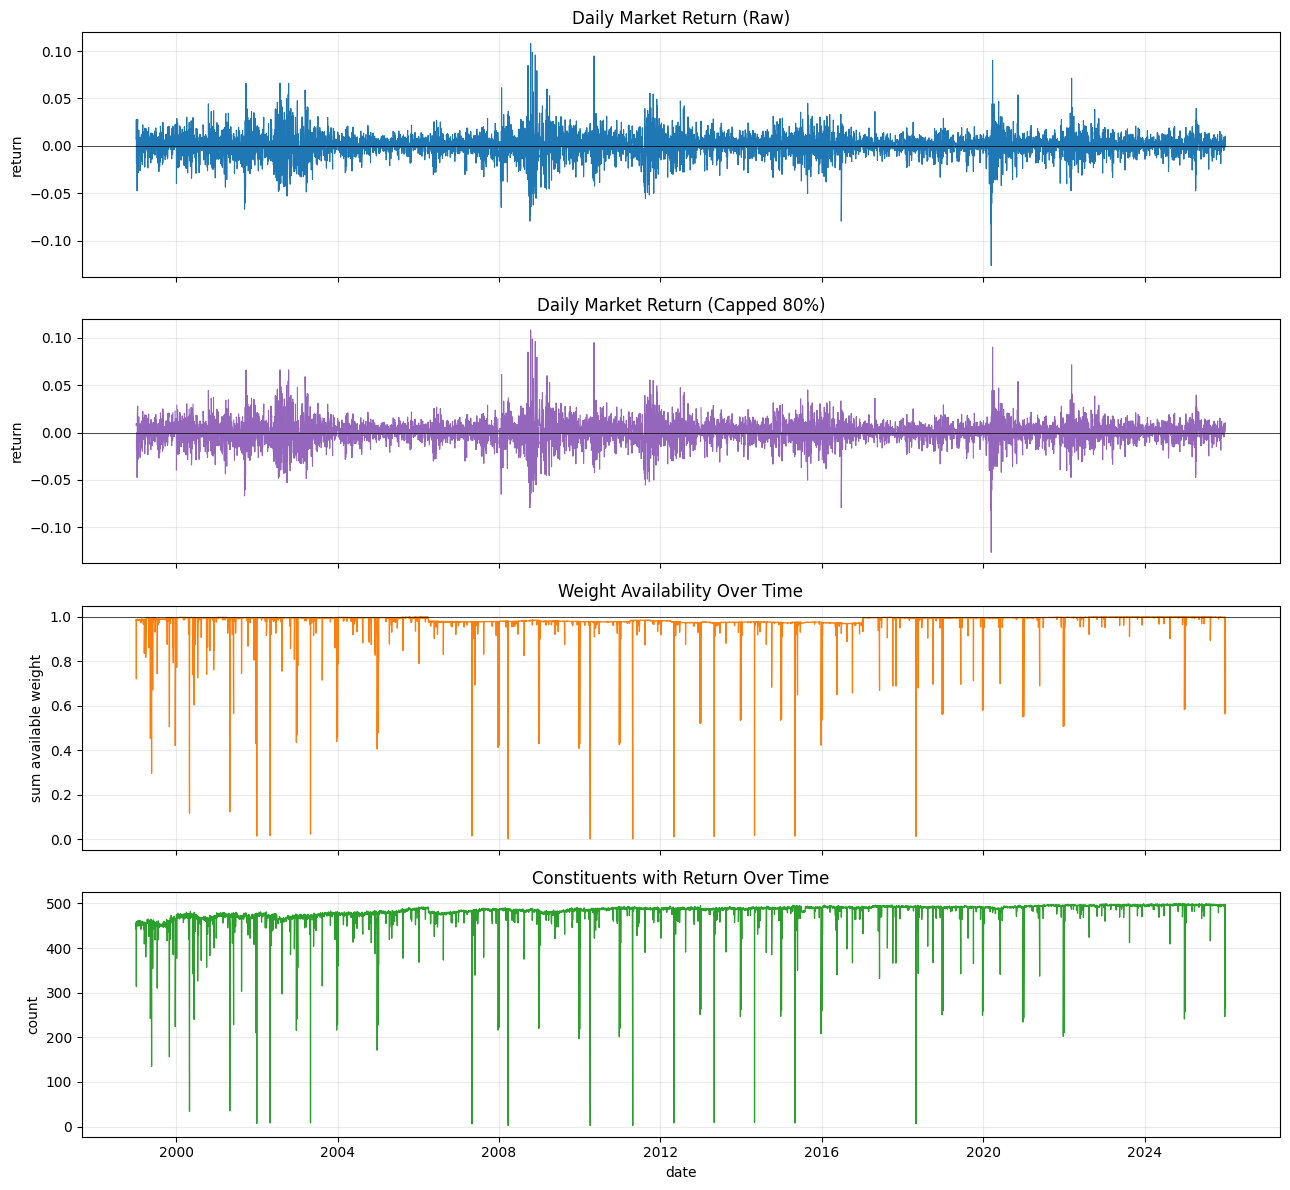

Worst 10 days by market return:


,date,quarter,market_return_ffmcap,weight_available,n_constituents_with_return
5438,2020-03-12,2020Q1,-0.126368,0.994488,490
5435,2020-03-09,2020Q1,-0.082152,0.994540,490
4487,2016-06-24,2016Q2,-0.079396,0.925171,469
2505,2008-10-06,2008Q4,-0.079374,0.980910,484
2509,2008-10-10,2008Q4,-0.073235,0.980273,484
691,2001-09-11,2001Q3,-0.066810,0.995470,472
2321,2008-01-21,2008Q1,-0.064975,0.980224,488
2512,2008-10-15,2008Q4,-0.064242,0.984942,486
2528,2008-11-06,2008Q4,-0.062354,0.983606,481
5440,2020-03-16,2020Q1,-0.060819,0.995410,491


Days with lowest weight availability:


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
2886,2010-04-05,2010Q2,0.023721,NaN,0.000448,2
3160,2011-04-25,2011Q2,0.004230,NaN,0.000613,2
2366,2008-03-24,2008Q1,-0.009919,NaN,0.000641,2
3423,2012-05-01,2012Q2,0.010464,NaN,0.009725,8
3679,2013-05-01,2013Q2,0.008779,NaN,0.011695,9
4960,2018-05-01,2018Q2,0.004009,NaN,0.011815,6
4191,2015-05-01,2015Q2,0.011996,NaN,0.013182,8
768,2001-12-31,2001Q4,0.000381,NaN,0.013370,7
2135,2007-05-01,2007Q2,0.003097,NaN,0.013629,6
852,2002-05-01,2002Q2,-0.009863,NaN,0.015310,8


In [141]:
import matplotlib.pyplot as plt

diag = market_daily_out.copy()
diag["date"] = pd.to_datetime(diag["date"], errors="coerce")
diag = diag.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

stats = {
    "obs_days": int(len(diag)),
    "start": diag["date"].min(),
    "end": diag["date"].max(),
    "mean_daily_return": float(diag["market_return_ffmcap"].mean()),
    "vol_daily_return": float(diag["market_return_ffmcap"].std()),
    "mean_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].mean()),
    "vol_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].std()),
    "mean_weight_available": float(diag["weight_available"].mean()),
    "p5_weight_available": float(diag["weight_available"].quantile(0.05)),
    "mean_constituents_with_return": float(diag["n_constituents_with_return"].mean()),
}
print("Market index diagnostics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(diag["date"], diag["market_return_ffmcap"], lw=0.8, color="tab:blue")
axes[0].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[0].set_title("Daily Market Return (Raw)")
axes[0].set_ylabel("return")
axes[0].grid(alpha=0.25)

axes[1].plot(diag["date"], diag["market_return_ffmcap_capped80"], lw=0.8, color="tab:purple")
axes[1].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[1].set_title("Daily Market Return (Capped 80%)")
axes[1].set_ylabel("return")
axes[1].grid(alpha=0.25)

axes[2].plot(diag["date"], diag["weight_available"], color="tab:orange", lw=0.9)
axes[2].axhline(1.0, color="black", lw=0.7, alpha=0.7)
axes[2].set_title("Weight Availability Over Time")
axes[2].set_ylabel("sum available weight")
axes[2].grid(alpha=0.25)

axes[3].plot(diag["date"], diag["n_constituents_with_return"], color="tab:green", lw=0.9)
axes[3].set_title("Constituents with Return Over Time")
axes[3].set_ylabel("count")
axes[3].set_xlabel("date")
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Worst 10 days by market return:")
display(
    diag.nsmallest(10, "market_return_ffmcap")[
        ["date", "quarter", "market_return_ffmcap", "weight_available", "n_constituents_with_return"]
    ]
)

print("Days with lowest weight availability:")
display(
    diag.nsmallest(10, "weight_available")[
        ["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available", "n_constituents_with_return"]
    ]
)


## 6. Benchmark Pull and Comparison (STOXX 600, STOXX EURO 50)

External benchmark data is pulled to evaluate tracking properties.

Comparison dimensions:
- Level and cumulative return paths
- Correlation and co-movement
- Relative performance across subperiods


In [142]:
def pull_index_daily_return(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """
    Pull daily benchmark returns from LSEG using Total-Return-like fields only.
    """
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid benchmark date bounds for {ric}: start={start}, end={end}")

    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")

    tr_fields = [
        "TR.TotalReturn",
        "TR.IndexTotalReturn",
        "TR.IndexGrossReturn",
        "TR.IndexNetReturn",
    ]
    price_fields = [
        "TR.PriceClose",
        "CLOSE",
    ]

    last_err = None
    tried = []

    def _coerce_num(s: pd.Series) -> pd.Series:
        # Handles values like "0.45%", "1,234.5", etc.
        t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
        t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
        return pd.to_numeric(t, errors="coerce")

    for field in tr_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            # Choose the column that yields the most numeric observations.
            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 0:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if out.empty:
                continue

            # TR-like series can come as percent points or decimals.
            max_abs = out["value"].abs().quantile(0.99)
            out["ret"] = out["value"] / 100.0 if max_abs > 1.5 else out["value"]
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = field
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    # Fallback for return-index RICs (e.g., .STOXXR/.STOXX50ER):
    # use index level (PriceClose/Close) and convert to daily returns.
    # This remains TR-consistent because the RIC itself is a return index.
    for field in price_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 1:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if len(out) <= 1:
                continue

            out["ret"] = out["value"].pct_change()
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = f"{field}->pct_change"
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    msg = f"No usable TR benchmark series for {ric}. Tried fields: {tried}"
    if last_err is not None:
        msg += f" | last error: {type(last_err).__name__}: {last_err}"
    raise ValueError(msg)


# File cache for benchmark pulls to avoid repeated LSEG requests.
BENCH_CACHE_DIR = DATA_DIR / "benchmark_cache"
BENCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
BENCH_CACHE_SCHEMA_VERSION = "v2"

def _bench_cache_path(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> Path:
    ric_key = str(ric).replace(".", "_dot_").replace("/", "_")
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return BENCH_CACHE_DIR / f"bench_{BENCH_CACHE_SCHEMA_VERSION}_{ric_key}_{s}_{e}.parquet"

def pull_index_daily_return_cached(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    cache_path = _bench_cache_path(ric=ric, start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"Cache hit: {ric} -> {cache_path.name}")
        return out

    print(f"Cache miss: {ric} -> pulling from LSEG")
    ld.open_session()
    try:
        out = pull_index_daily_return(ric=ric, start=start, end=end)
    finally:
        ld.close_session()

    out.to_parquet(cache_path, index=False)
    return out


def _resolve_benchmark_bounds() -> tuple[pd.Timestamp, pd.Timestamp]:
    candidates = []

    # Primary source: market index daily output.
    if "market_daily_out" in globals() and isinstance(market_daily_out, pd.DataFrame) and "date" in market_daily_out.columns:
        d = pd.to_datetime(market_daily_out["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "market_daily_out"))

    # Fallback: in-index stock returns.
    if "returns_in_index" in globals() and isinstance(returns_in_index, pd.DataFrame) and "date" in returns_in_index.columns:
        d = pd.to_datetime(returns_in_index["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "returns_in_index"))

    if not candidates:
        raise ValueError("Could not resolve benchmark date bounds (no valid dates in market_daily_out/returns_in_index).")

    # Prefer the first candidate (market_daily_out), otherwise fallback already handled.
    start_dt, end_dt, src = candidates[0]
    print(f"Benchmark date bounds from {src}: {start_dt.date()} -> {end_dt.date()}")
    return start_dt, end_dt


start_dt, end_dt = _resolve_benchmark_bounds()

bench_list = [
    (".STOXXR", "stoxx600_ret"),
    (".STOXX50ER", "stoxx_euro50_ret"),
]

bench_frames = []
bench_meta = []

for ric, col_name in bench_list:
    b = pull_index_daily_return_cached(ric=ric, start=start_dt, end=end_dt).rename(columns={"ret": col_name})
    if b.empty:
        raise ValueError(f"Benchmark pull returned empty frame for {ric}")
    bench_meta.append(
        b[["ric", "field_used", "is_total_return"]]
        .drop_duplicates()
        .assign(series=col_name)
    )
    bench_frames.append(b[["date", col_name]])

bench_info = pd.concat(bench_meta, ignore_index=True)
print("Benchmark fields used:")
display(bench_info)

if len(bench_frames) != len(bench_list):
    raise ValueError("Not all benchmark TR series were pulled successfully (.STOXXR / .STOXX50ER).")

cmp_df = market_daily_out[["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available"]].copy()
for bf in bench_frames:
    cmp_df = cmp_df.merge(bf, on="date", how="left")

print("Comparison frame date range:", cmp_df["date"].min(), "to", cmp_df["date"].max())
print("Missing benchmark shares:")
for c in ["stoxx600_ret", "stoxx_euro50_ret"]:
    print(f"  {c}: {cmp_df[c].isna().mean():.2%}")

display(cmp_df.head())
display(cmp_df.tail())





Benchmark date bounds from market_daily_out: 1999-01-04 -> 2025-12-31
Cache hit: .STOXXR -> bench_v2__dot_STOXXR_19990104_20251231.parquet
Cache hit: .STOXX50ER -> bench_v2__dot_STOXX50ER_19990104_20251231.parquet
Benchmark fields used:


,ric,field_used,is_total_return,series
0,.STOXXR,TR.PriceClose->pct_change,True,stoxx600_ret
1,.STOXX50ER,TR.PriceClose->pct_change,True,stoxx_euro50_ret


Comparison frame date range: 1999-01-04 00:00:00 to 2025-12-31 00:00:00
Missing benchmark shares:
  stoxx600_ret: 21.48%
  stoxx_euro50_ret: 21.35%


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,stoxx600_ret,stoxx_euro50_ret
0,1999-01-04,1999Q1,0.007363,0.007363,0.985497,NaN,NaN
1,1999-01-05,1999Q1,0.009426,0.009426,0.987099,NaN,NaN
2,1999-01-06,1999Q1,0.027771,NaN,0.720274,NaN,NaN
3,1999-01-07,1999Q1,-0.018186,-0.018186,0.987186,NaN,NaN
4,1999-01-08,1999Q1,-0.000398,-0.000398,0.987005,NaN,NaN


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,stoxx600_ret,stoxx_euro50_ret
6921,2025-12-23,2025Q4,0.000168,0.000168,0.997898,0.003400,0.000975
6922,2025-12-24,2025Q4,-0.000686,NaN,0.563170,-0.000054,-0.000529
6923,2025-12-29,2025Q4,0.001556,0.001556,0.998342,0.001073,0.000951
6924,2025-12-30,2025Q4,0.010329,0.010329,0.998327,0.005983,0.007739
6925,2025-12-31,2025Q4,-0.000906,NaN,0.571933,-0.000870,-0.000496


## 7. Relative Performance Views

Additional relative metrics and plots, such as:
- Return spreads vs benchmark
- Rolling excess performance
- Drawdown and recovery comparison


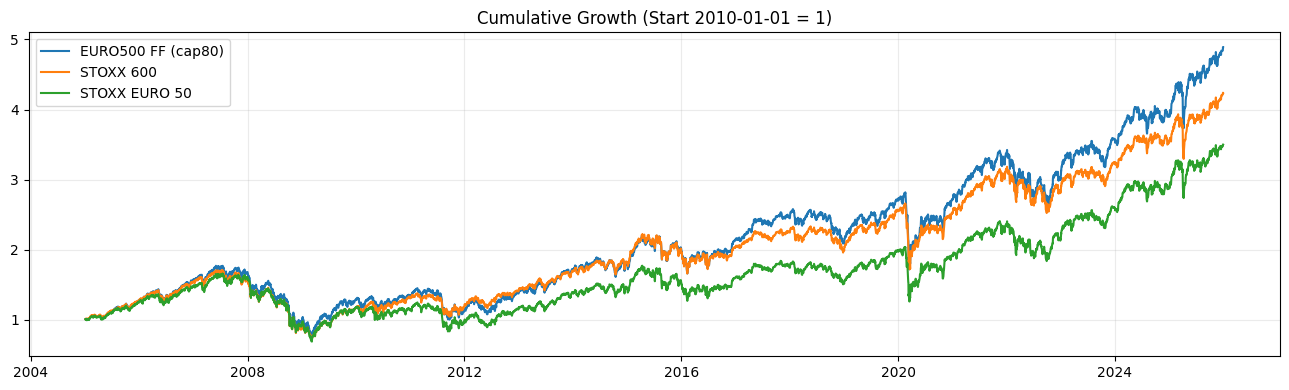

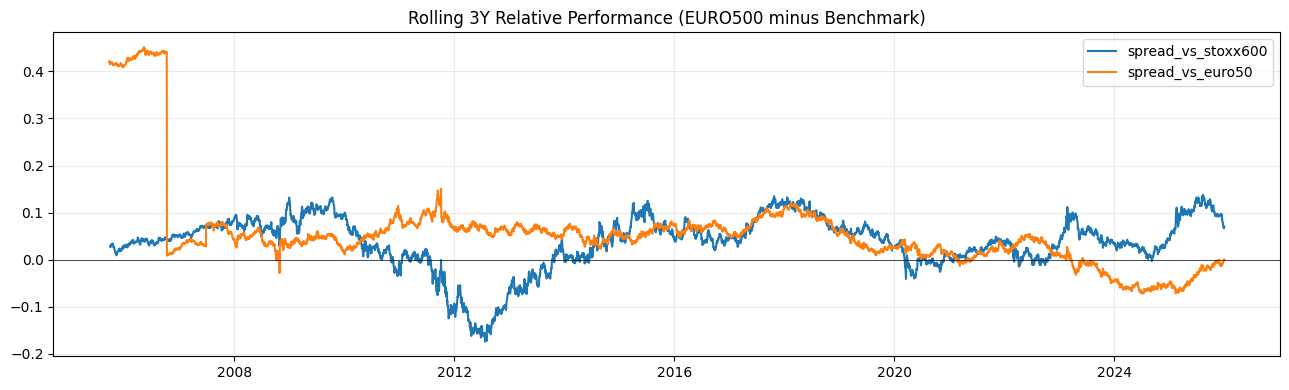

Annual return spread table:


In [143]:
def _normalized_cum_level(ret: pd.Series, base: float = 1.0) -> pd.Series:
    """Convert daily returns into a normalized cumulative level."""
    r = pd.to_numeric(ret, errors="coerce")
    out = (1.0 + r.fillna(0.0)).cumprod() * float(base)
    return out

cmp_plot = cmp_df.copy()
cmp_plot["date"] = pd.to_datetime(cmp_plot["date"], errors="coerce")
cmp_plot = cmp_plot.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

START_NORM = pd.Timestamp("2005-01-01")
cmp_norm = cmp_plot[cmp_plot["date"] >= START_NORM].copy()

series_cols = [
    "market_return_ffmcap_capped80",
    "stoxx600_ret",
    "stoxx_euro50_ret",
]
series_cols = [c for c in series_cols if c in cmp_norm.columns]

for c in series_cols:
    cmp_norm[f"lvl_{c}"] = _normalized_cum_level(cmp_norm[c])

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
if "lvl_market_return_ffmcap_capped80" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_market_return_ffmcap_capped80"], label="EURO500 FF (cap80)")
if "lvl_stoxx600_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx600_ret"], label="STOXX 600")
if "lvl_stoxx_euro50_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx_euro50_ret"], label="STOXX EURO 50")
ax.set_title("Cumulative Growth (Start 2010-01-01 = 1)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 3Y (756 trading days) rolling relative performance vs benchmarks
rolling_win = 756
rel = cmp_plot[["date", "market_return_ffmcap_capped80"]].copy()
if "stoxx600_ret" in cmp_plot.columns:
    rel["spread_vs_stoxx600"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx600_ret"]
if "stoxx_euro50_ret" in cmp_plot.columns:
    rel["spread_vs_euro50"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx_euro50_ret"]

roll = rel[["date"]].copy()
for c in [x for x in rel.columns if x.startswith("spread_")]:
    # Robust rolling sum: allow partial missing observations but require enough valid days.
    valid_cnt = rel[c].notna().rolling(rolling_win, min_periods=1).sum()
    rsum = rel[c].fillna(0.0).rolling(rolling_win, min_periods=252).sum()
    rsum[valid_cnt < 252] = np.nan
    roll[f"roll3y_{c}"] = rsum

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
for c in [x for x in roll.columns if x.startswith("roll3y_")]:
    ax.plot(roll["date"], roll[c], label=c.replace("roll3y_", ""))
ax.axhline(0.0, color="black", lw=0.7, alpha=0.7)
ax.set_title("Rolling 3Y Relative Performance (EURO500 minus Benchmark)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Yearly return spread table
annual = cmp_plot.copy()
annual["year"] = annual["date"].dt.year
ann_rows = []
for y, g in annual.groupby("year"):
    row = {"year": int(y)}
    if g["market_return_ffmcap_capped80"].notna().any():
        row["euro500_ann"] = float((1 + g["market_return_ffmcap_capped80"].fillna(0)).prod() - 1)
    if "stoxx600_ret" in g.columns and g["stoxx600_ret"].notna().any():
        row["stoxx600_ann"] = float((1 + g["stoxx600_ret"].fillna(0)).prod() - 1)
        row["spread_vs_stoxx600"] = row.get("euro500_ann", np.nan) - row["stoxx600_ann"]
    if "stoxx_euro50_ret" in g.columns and g["stoxx_euro50_ret"].notna().any():
        row["stoxx_euro50_ann"] = float((1 + g["stoxx_euro50_ret"].fillna(0)).prod() - 1)
        row["spread_vs_euro50"] = row.get("euro500_ann", np.nan) - row["stoxx_euro50_ann"]
    ann_rows.append(row)

annual_spread = pd.DataFrame(ann_rows).sort_values("year").reset_index(drop=True)
print("Annual return spread table:")



## 8. Hard Validation Tests

Strict consistency checks to catch construction errors.

Examples:
- Exactly 500 constituents where expected
- Weight sums close to 1 per rebalance date
- No duplicate constituent-date rows
- Valid date alignment between constituents and returns


In [144]:
def _te(a: pd.Series, b: pd.Series) -> float:
    z = pd.concat([a, b], axis=1).dropna()
    if z.empty:
        return np.nan
    return float((z.iloc[:, 0] - z.iloc[:, 1]).std())


def _beta(a: pd.Series, b: pd.Series) -> float:
    z = pd.concat([a, b], axis=1).dropna()
    if len(z) < 3:
        return np.nan
    x = z.iloc[:, 0]
    y = z.iloc[:, 1]
    var_y = np.var(y)
    if var_y <= 0:
        return np.nan
    return float(np.cov(x, y)[0, 1] / var_y)


# Test 1: scale sanity (daily return magnitude should be plausible)
scale_rows = []
for c in ["market_return_ffmcap", "market_return_ffmcap_capped80", "stoxx600_ret", "stoxx_euro50_ret"]:
    if c in cmp_df.columns:
        x = pd.to_numeric(cmp_df[c], errors="coerce").dropna()
        if len(x) == 0:
            continue
        q95 = float(x.abs().quantile(0.95))
        q99 = float(x.abs().quantile(0.99))
        mx = float(x.abs().max())
        scale_rows.append({
            "series": c,
            "n": int(len(x)),
            "abs_q95": q95,
            "abs_q99": q99,
            "abs_max": mx,
            "scale_flag": "WARN" if q99 > 0.20 else "PASS",
        })
scale_df = pd.DataFrame(scale_rows)

# Test 2: cap impact
raw = pd.to_numeric(market_daily_out["market_return_ffmcap"], errors="coerce")
cap = pd.to_numeric(market_daily_out["market_return_ffmcap_capped80"], errors="coerce")
wa = pd.to_numeric(market_daily_out["weight_available"], errors="coerce")
dropped = int(cap.isna().sum())
cap_test = pd.DataFrame([{
    "n_days": int(len(market_daily_out)),
    "dropped_days_cap80": dropped,
    "drop_share": float(dropped / len(market_daily_out)) if len(market_daily_out) else np.nan,
    "raw_vol": float(raw.std()),
    "cap80_vol": float(cap.std()),
    "raw_abs_q99": float(raw.abs().quantile(0.99)),
    "cap80_abs_q99": float(cap.abs().quantile(0.99)),
}])

# Test 3: outlier/availability linkage
z = (raw - raw.mean()) / raw.std()
outlier = z.abs() > 3
link_test = pd.DataFrame([{
    "corr_absret_vs_missing_weight": float(raw.abs().corr(1 - wa)),
    "corr_outlier_vs_missing_weight": float(outlier.astype(float).corr(1 - wa)),
}])

# Test 4: benchmark alignment raw vs cap80
bench_rows = []
for rhs in ["stoxx600_ret", "stoxx_euro50_ret"]:
    if rhs in cmp_df.columns:
        for lhs in ["market_return_ffmcap", "market_return_ffmcap_capped80"]:
            zz = pd.concat([cmp_df[lhs], cmp_df[rhs]], axis=1).dropna()
            corr = float(zz.iloc[:, 0].corr(zz.iloc[:, 1])) if len(zz) else np.nan
            bench_rows.append({
                "lhs": lhs,
                "rhs": rhs,
                "n": int(len(zz)),
                "corr": corr,
                "beta": _beta(cmp_df[lhs], cmp_df[rhs]),
                "tracking_error": _te(cmp_df[lhs], cmp_df[rhs]),
                "alignment_flag": "PASS" if (pd.notna(corr) and corr >= 0.70) else "WARN",
            })
bench_test = pd.DataFrame(bench_rows)

# Test 5: fragile days (very low availability and very few names)
fragile = market_daily_out[
    (market_daily_out["weight_available"] < 0.80)
    | (market_daily_out["n_constituents_with_return"] < 50)
].copy()
fragile = fragile.sort_values(["weight_available", "n_constituents_with_return"]).head(20)

print("Hard test 1: scale sanity")
display(scale_df)
print("Hard test 2: cap impact (80%)")
display(cap_test)
print("Hard test 3: outlier vs availability linkage")
display(link_test)
print("Hard test 4: benchmark alignment")
display(bench_test)
print("Hard test 5: fragile days (lowest availability / few constituents)")
display(fragile[["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available", "n_constituents_with_return"]])


Hard test 1: scale sanity


,series,n,abs_q95,abs_q99,abs_max,scale_flag
0,market_return_ffmcap,6926,0.026278,0.043959,0.126368,PASS
1,market_return_ffmcap_capped80,6840,0.026298,0.044234,0.126368,PASS
2,stoxx600_ret,5438,0.022347,0.037762,0.114640,PASS
3,stoxx_euro50_ret,5447,0.026736,0.046798,0.413521,PASS


Hard test 2: cap impact (80%)


,n_days,dropped_days_cap80,drop_share,raw_vol,cap80_vol,raw_abs_q99,cap80_abs_q99
0,6926,86,0.012417,0.012929,0.012976,0.043959,0.044234


Hard test 3: outlier vs availability linkage


,corr_absret_vs_missing_weight,corr_outlier_vs_missing_weight
0,-0.02441,-0.014036


Hard test 4: benchmark alignment


,lhs,rhs,n,corr,beta,tracking_error,alignment_flag
0,market_return_ffmcap,stoxx600_ret,5438,0.973911,1.080417,0.002948,PASS
1,market_return_ffmcap_capped80,stoxx600_ret,5393,0.974232,1.080171,0.002940,PASS
2,market_return_ffmcap,stoxx_euro50_ret,5447,0.900150,0.781806,0.006223,PASS
3,market_return_ffmcap_capped80,stoxx_euro50_ret,5398,0.900402,0.781468,0.006243,PASS


Hard test 5: fragile days (lowest availability / few constituents)


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
2886,2010-04-05,2010Q2,0.023721,NaN,0.000448,2
3160,2011-04-25,2011Q2,0.004230,NaN,0.000613,2
2366,2008-03-24,2008Q1,-0.009919,NaN,0.000641,2
3423,2012-05-01,2012Q2,0.010464,NaN,0.009725,8
3679,2013-05-01,2013Q2,0.008779,NaN,0.011695,9
4960,2018-05-01,2018Q2,0.004009,NaN,0.011815,6
4191,2015-05-01,2015Q2,0.011996,NaN,0.013182,8
768,2001-12-31,2001Q4,0.000381,NaN,0.013370,7
2135,2007-05-01,2007Q2,0.003097,NaN,0.013629,6
852,2002-05-01,2002Q2,-0.009863,NaN,0.015310,8


In [145]:
cov_by_q = (
    panel_all
    .groupby("date")["mcap_eur"]
    .apply(lambda s: s.notna().mean())
    .rename("mcap_coverage")
    .reset_index()
)

cov_by_q["n_universe"] = panel_all.groupby("date")["RIC"].nunique().values
cov_by_q["n_top500"] = euro500.groupby("date")["RIC"].nunique().reindex(cov_by_q["date"]).fillna(0).astype(int).values

print("Median mcap coverage:", f"{cov_by_q['mcap_coverage'].median():.1%}")
print("Worst 10 quarters by coverage:")
cov_by_q.sort_values("mcap_coverage").head(10)





Median mcap coverage: 100.0%
Worst 10 quarters by coverage:


,date,mcap_coverage,n_universe,n_top500
0,1998-12-31,1.0,611,500
78,2018-06-29,1.0,1500,500
77,2018-03-30,1.0,1500,500
76,2017-12-29,1.0,1500,500
75,2017-09-29,1.0,1500,500
74,2017-06-30,1.0,1500,500
73,2017-03-31,1.0,1500,500
72,2016-12-30,1.0,1500,500
71,2016-09-30,1.0,1500,500
70,2016-06-30,1.0,1500,500


In [146]:
euro500["RIC"].nunique()

1426

In [147]:
def assert_euro500_hq_countries_ok(euro500: pd.DataFrame) -> None:
    """
    Prints 'OK ✅' if, for every quarter, all HQ countries present in euro500
    are euro-eligible for the subsequent return period (per euro_hq_codes_for_quarter).
    Otherwise prints a short FAIL message.
    """
    for dt, g in euro500.groupby("date"):
        formation_date = pd.Timestamp(dt).normalize()
        allowed = set(euro_hq_codes_for_quarter(formation_date))

        present = set(
            g["hq_code"]
            .dropna()
            .astype(str)
            .str.strip()
            .str.upper()
            .unique()
        )

        viol = sorted(present - allowed)

        if len(viol) > 0:
            print("FAIL ❌")
            print("First problematic quarter (formation):", formation_date.date())
            print("Countries present but not euro-eligible:", viol)
            return

    print("OK ✅ All HQ countries in euro500 are correctly euro-eligible in every quarter.")

assert_euro500_hq_countries_ok(euro500)

def assert_euro500_start_date_before_quarter_start(euro500: pd.DataFrame) -> None:
    """
    Prints 'OK ✅' if every non-missing start_date is strictly before quarter start (effective_date).
    start_date = FirstTradeDate if available, else IPODate, with IPO fallback when FirstTradeDate is implausibly late.
    """
    required = {"effective_date"}
    if not required.issubset(euro500.columns):
        print(f"SKIP ⚠️ Start-date check skipped. Missing columns: {sorted(required - set(euro500.columns))}")
        return

    x = euro500.copy()
    x["effective_date"] = pd.to_datetime(x["effective_date"], errors="coerce").dt.normalize()

    if "first_trade_date" not in x.columns:
        x["first_trade_date"] = pd.NaT
    if "ipo_date" not in x.columns:
        x["ipo_date"] = pd.NaT

    x["first_trade_date"] = pd.to_datetime(x["first_trade_date"], errors="coerce").dt.normalize()
    x["ipo_date"] = pd.to_datetime(x["ipo_date"], errors="coerce").dt.normalize()
    x["start_date"] = x["first_trade_date"].where(x["first_trade_date"].notna(), x["ipo_date"])

    ftd_implausible = (
        x["first_trade_date"].notna()
        & x["ipo_date"].notna()
        & x["effective_date"].notna()
        & (x["first_trade_date"] >= x["effective_date"])
        & (x["ipo_date"] < x["effective_date"])
    )
    x.loc[ftd_implausible, "start_date"] = x.loc[ftd_implausible, "ipo_date"]

    viol = x["start_date"].notna() & x["effective_date"].notna() & (x["start_date"] >= x["effective_date"])
    if bool(viol.any()):
        b = x.loc[viol, ["date", "quarter", "effective_date", "first_trade_date", "ipo_date", "start_date", "RIC", "name"]].iloc[0]
        print("FAIL ❌")
        print("First start_date violation found:")
        print(b.to_string())
        return

    print("OK ✅ All start_date values are strictly before quarter start (effective_date).")

assert_euro500_start_date_before_quarter_start(euro500)


OK ✅ All HQ countries in euro500 are correctly euro-eligible in every quarter.
OK ✅ All start_date values are strictly before quarter start (effective_date).


## 9. Analysis

This section summarizes key empirical properties of the constructed universe and index.

Focus:
- How close the custom EURO500 is to standard benchmarks
- Where and when deviations are strongest


In [148]:
country_share = (
    euro500
    .groupby(["date", "hq_code"])["RIC"]
    .nunique()
    .groupby("hq_code")
    .mean()
    .sort_values(ascending=False)
)

country_share_pct = 100 * country_share / country_share.sum()

country_share_pct.head(15)


hq_code
FR    23.659619
DE    22.041806
IT    10.822303
ES     8.602344
BE     6.908355
NL     6.775955
FI     5.782052
AT     4.704718
GR     3.213204
PT     2.261675
IE     1.465464
LU     1.224242
HR     0.605444
MT     0.497638
SI     0.475333
Name: RIC, dtype: float64

In [149]:
sector_share = (
    euro500
    .groupby(["date", "trbc_sector"])["RIC"]
    .nunique()
    .groupby("trbc_sector")
    .mean()
    .sort_values(ascending=False)
)

sector_share_pct = 100 * sector_share / sector_share.sum()
sector_share_pct


trbc_sector
Industrials                                   18.320414
Consumer Cyclicals                            15.766603
Financials                                    14.774171
Technology                                    10.850472
Basic Materials                               10.147116
Consumer Non-Cyclicals                         6.891790
Healthcare                                     6.854965
Real Estate                                    5.879104
Utilities                                      5.626853
Energy                                         4.291948
Academic & Educational Services                0.397709
Institutions, Associations & Organizations     0.198855
Name: RIC, dtype: float64

### 9.0 Quartalsweiser Indexwechsel: Anzahl Ausscheider

Diese Grafik zeigt pro Rebalancing-Quartal, wie viele Unternehmen aus dem EURO500 gegenüber dem Vorquartal ausgeschieden sind.


,date,quarter,n_leavers,n_entrants
96,2022-12-30,2022Q4,14.0,14.0
97,2023-03-31,2023Q1,21.0,21.0
98,2023-06-30,2023Q2,12.0,12.0
99,2023-09-29,2023Q3,14.0,14.0
100,2023-12-29,2023Q4,12.0,12.0
101,2024-03-29,2024Q1,17.0,17.0
102,2024-06-28,2024Q2,15.0,15.0
103,2024-09-30,2024Q3,15.0,15.0
104,2024-12-31,2024Q4,14.0,14.0
105,2025-03-31,2025Q1,19.0,19.0


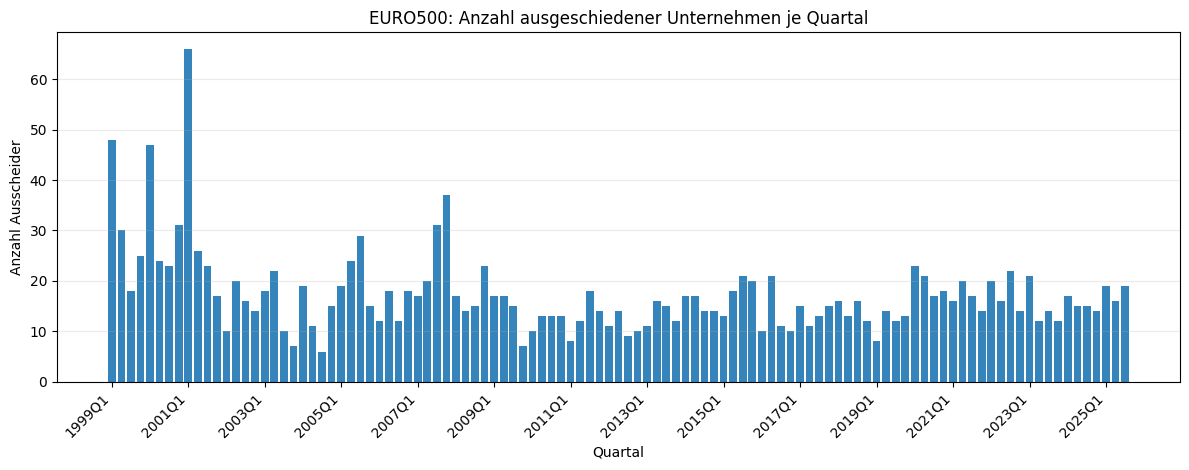

In [150]:
if "euro500" not in globals():
    raise RuntimeError("euro500 not found. Run portfolio construction sections first.")

if "date" not in euro500.columns or "RIC" not in euro500.columns:
    raise KeyError("euro500 must contain columns 'date' and 'RIC'.")

m = euro500[["date", "RIC"]].copy()
m["date"] = pd.to_datetime(m["date"]).dt.normalize()

if "normalize_ric" in globals():
    m["RIC_norm"] = normalize_ric(m["RIC"])  # consistent with earlier helper logic
else:
    m["RIC_norm"] = m["RIC"].astype(str).str.strip().str.upper()

m = m.dropna(subset=["date", "RIC_norm"]).drop_duplicates(["date", "RIC_norm"])

quarter_sets = (
    m.groupby("date")["RIC_norm"]
    .agg(lambda s: set(s.astype(str)))
    .sort_index()
)

rows = []
prev = None
for dt, cur in quarter_sets.items():
    leavers = np.nan if prev is None else len(prev - cur)
    entrants = np.nan if prev is None else len(cur - prev)
    rows.append({"date": dt, "quarter": pd.Period(dt, freq="Q"), "n_leavers": leavers, "n_entrants": entrants})
    prev = cur

turnover_quarterly = pd.DataFrame(rows)
display(turnover_quarterly.tail(12))

plot_df = turnover_quarterly.dropna(subset=["n_leavers"]).copy()
plot_df["quarter_label"] = plot_df["quarter"].astype(str)

plt.figure(figsize=(12, 4.8))
plt.bar(plot_df["quarter_label"], plot_df["n_leavers"], color="#1f77b4", alpha=0.9)
plt.title("EURO500: Anzahl ausgeschiedener Unternehmen je Quartal")
plt.xlabel("Quartal")
plt.ylabel("Anzahl Ausscheider")

n = len(plot_df)
if n > 0:
    step = max(1, n // 12)
    tick_idx = np.arange(0, n, step)
    plt.xticks(tick_idx, plot_df["quarter_label"].iloc[tick_idx], rotation=45, ha="right")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### 9.1 STOXX600 EuroHQ vs EURO500 (Name Overlap, Static)

This subsection compares simple company-name coverage between:
- The full STOXX600 EuroHQ membership matrix (all available rows)
- The EURO500 universe

No quarterly or time dimension is used.



Static name overlap summary (no time dimension):


,n_stoxx_unique_names,n_euro500_unique_names,n_intersection,share_stoxx_covered_by_euro500,share_euro500_covered_by_stoxx
0,650,1166,422,0.649231,0.361921


Examples: STOXX names missing in EURO500 (first 50)


,NAME_norm
0,AAREALBANKAG
1,ABENGOAENLIQUIDACIONSA
2,ABNAMROBANKNV
3,AEROPORTIDIROMASPA
4,ALAPISHOLDINGINDUSTRIALANDCOMMERCIALPHARMACEUT...
5,ALITALIALINEEAEREEITALIANESPA
6,ALLEGROEUSA
7,ALSTRIAOFFICEAG
8,ALTANAAG
9,ALTICEEUROPENV


Examples: EURO500 names missing in STOXX (first 50)


,NAME_norm
0,11880SOLUTIONSAG
1,2INVESTAG
2,3UHOLDINGAG
3,74SOFTWARESA
4,ABCARBITRAGESA
5,ABSCIENCESA
6,ACANTHEDEVELOPPEMENTSE
7,ACERINOXSA
8,ACINQUESPA
9,ACOMONV


Year-count table: years in STOXX for names missing in EURO500 (top 20)


,NAME_norm,n_years_in_stx
0,UNIBAILRODAMCOWESTFIELDSE,27
1,ALLEGROEUSA,27
2,EXPERIANPLC,27
3,MAGNUMICECREAMCOMPANYNV,27
4,BMEUROPEANVALUERETAILSA,27
5,DCCPLC,27
6,FRONTLINEPLC,27
7,ABNAMROBANKNV,27
8,DSMBV,24
9,CNPASSURANCESSA,23


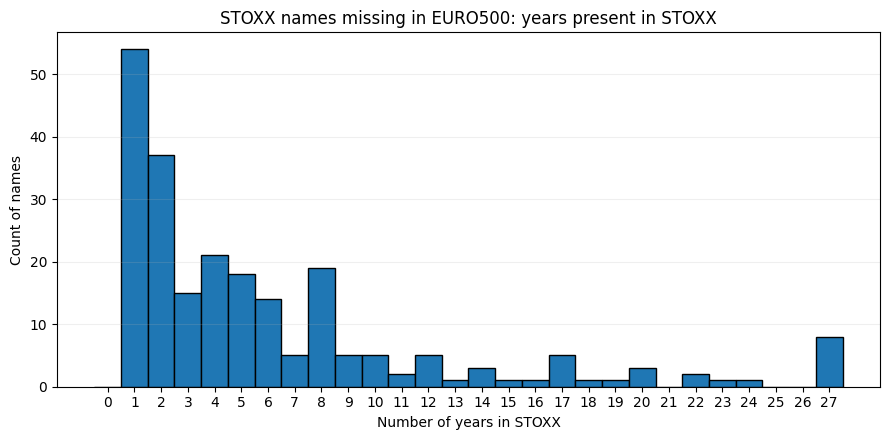

In [151]:
STOXX_EUROHQ_PATH = DATA_DIR / "stoxx600_membership_matrix_1999_2025_eurohq.parquet"
if not STOXX_EUROHQ_PATH.exists():
    raise FileNotFoundError(f"Missing file: {STOXX_EUROHQ_PATH}")

stx = pd.read_parquet(STOXX_EUROHQ_PATH).copy()
euro_cmp = euro500.copy()

def normalize_name(x: pd.Series) -> pd.Series:
    s = x.astype(str).str.strip().str.upper()
    # Robust against punctuation and whitespace variants.
    s = s.str.replace(r"[^A-Z0-9]+", "", regex=True)
    s = s.replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    return s

if "CompanyName" not in stx.columns:
    raise KeyError("Column 'CompanyName' not found in STOXX matrix.")

name_col_euro = "name" if "name" in euro_cmp.columns else ("CompanyName" if "CompanyName" in euro_cmp.columns else None)
if name_col_euro is None:
    raise KeyError("No company-name column found in euro500 (expected 'name' or 'CompanyName').")

# -------- Static name overlap (no time dimension) --------
stx_names = normalize_name(stx["CompanyName"]).dropna()
euro_names = normalize_name(euro_cmp[name_col_euro]).dropna()

stx_set = set(stx_names.astype(str))
euro_set = set(euro_names.astype(str))
intersection = stx_set & euro_set

name_overlap_summary = pd.DataFrame([
    {
        "n_stoxx_unique_names": len(stx_set),
        "n_euro500_unique_names": len(euro_set),
        "n_intersection": len(intersection),
        "share_stoxx_covered_by_euro500": (len(intersection) / len(stx_set)) if stx_set else np.nan,
        "share_euro500_covered_by_stoxx": (len(intersection) / len(euro_set)) if euro_set else np.nan,
    }
])

stx_not_in_euro500 = pd.DataFrame({"NAME_norm": sorted(stx_set - euro_set)})
euro500_not_in_stx = pd.DataFrame({"NAME_norm": sorted(euro_set - stx_set)})

print("Static name overlap summary (no time dimension):")
display(name_overlap_summary)

print("Examples: STOXX names missing in EURO500 (first 50)")
display(stx_not_in_euro500.head(50))

print("Examples: EURO500 names missing in STOXX (first 50)")
display(euro500_not_in_stx.head(50))

# -------- Year-based distribution for missing names --------
year_cols = [c for c in stx.columns if str(c).isdigit()]
if not year_cols:
    raise ValueError("No year columns found in STOXX membership matrix.")

stx_year = stx[["CompanyName", *year_cols]].copy()
stx_year["NAME_norm"] = normalize_name(stx_year["CompanyName"])

for c in year_cols:
    stx_year[c] = pd.to_numeric(stx_year[c], errors="coerce").fillna(0).astype(int)

# Collapse potential duplicates at normalized-name level
name_year_membership = stx_year.groupby("NAME_norm")[year_cols].max()

records = []
for name_key in stx_not_in_euro500["NAME_norm"]:
    n_years = 0
    if name_key in name_year_membership.index:
        row = name_year_membership.loc[name_key]
        n_years = int((row == 1).sum())
    records.append({"NAME_norm": name_key, "n_years_in_stx": n_years})

stx_not_in_euro500_year_counts = pd.DataFrame(records).sort_values(
    "n_years_in_stx", ascending=False
).reset_index(drop=True)

print("Year-count table: years in STOXX for names missing in EURO500 (top 20)")
display(stx_not_in_euro500_year_counts.head(20))

import matplotlib.pyplot as plt

max_y = int(stx_not_in_euro500_year_counts["n_years_in_stx"].max()) if len(stx_not_in_euro500_year_counts) else 0
bins = range(0, max_y + 2)

plt.figure(figsize=(9, 4.5))
plt.hist(
    stx_not_in_euro500_year_counts["n_years_in_stx"],
    bins=bins,
    edgecolor="black",
    align="left",
)
plt.title("STOXX names missing in EURO500: years present in STOXX")
plt.xlabel("Number of years in STOXX")
plt.ylabel("Count of names")
if max_y > 0:
    step = max(1, max_y // 20)
    plt.xticks(range(0, max_y + 1, step))
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 9.2 Missing STOXX Top20: RIC-Level Root Cause Trace

Für die Top-20 aus `Year-count table: years in STOXX for names missing in EURO500`:
- mappt `NAME_norm` auf STOXX-RICs,
- prüft pro RIC und Quartal (nur Quartale, in denen der RIC laut STOXX-Jahresmatrix im Index ist),
- klassifiziert den ersten Ausschlussgrund:
  - in Step1: `fails_instrument_type`, `fails_financials_filter`, `missing_mcap`, `not_in_preselect_top1500`, `not_in_top500`, ...
  - nicht in Step1: `not_active_equity_or_ric_mismatch`, `fails_hq_filter`, `fails_public`, `fails_primary`.



In [152]:
# Configuration
TOP_N_MISSING = 20
ANALYZE_LAST_N_QUARTERS = None  # e.g. 20 for quick check, None for full history

if "stx_not_in_euro500_year_counts" not in globals() or "stx" not in globals():
    raise RuntimeError("Run section 9.1 first (stx_not_in_euro500_year_counts and stx must exist).")

if "rebalance_calendar" not in globals():
    raise RuntimeError("rebalance_calendar not found. Run the sample period/calendar section first.")

if "euro500" not in globals():
    raise RuntimeError("euro500 not found. Run EURO500 build section first.")


def _norm_set_from_col(df: pd.DataFrame, candidates: list[str]) -> set[str]:
    c = _best_col(df, candidates)
    if c is None or len(df) == 0:
        return set()
    vals = normalize_ric(df[c]).dropna().astype(str)
    return set(vals)


# Top-20 names by years in STOXX, then map to STOXX RIC(s)
top20_names = stx_not_in_euro500_year_counts.head(TOP_N_MISSING)["NAME_norm"].dropna().astype(str).tolist()

stx_map = stx.copy()
stx_map["NAME_norm"] = normalize_name(stx_map["CompanyName"])
stx_map["RIC_norm"] = normalize_ric(stx_map["ConstituentRIC"])

year_cols = [c for c in stx_map.columns if str(c).isdigit()]
if not year_cols:
    raise ValueError("No year columns found in STOXX membership matrix.")

for c in year_cols:
    stx_map[c] = pd.to_numeric(stx_map[c], errors="coerce").fillna(0).astype(int)

stx_top = stx_map[stx_map["NAME_norm"].isin(top20_names) & stx_map["RIC_norm"].notna()].copy()
stx_top = stx_top.drop_duplicates(subset=["NAME_norm", "RIC_norm"])  # map name->RICs

if stx_top.empty:
    raise ValueError("No STOXX RIC mapping found for top missing names.")


# Quarter frame
q_df = rebalance_calendar.copy()
q_df["quarter"] = q_df["quarter"].astype(str)
q_df["year"] = pd.to_datetime(q_df["formation_date"]).dt.year.astype(int)
if ANALYZE_LAST_N_QUARTERS is not None and ANALYZE_LAST_N_QUARTERS > 0:
    q_df = q_df.tail(ANALYZE_LAST_N_QUARTERS).copy()


trace_rows = []

print(f"9.2 mapping diagnostics: top20_names={len(top20_names)}, mapped_name_ric_rows={len(stx_top)}")

for _, rec in stx_top.iterrows():
    name_norm = rec["NAME_norm"]
    ric = rec["RIC_norm"]

    # quarters where this RIC is in STOXX by year-membership matrix
    years_in = [int(y) for y in year_cols if pd.to_numeric(rec.get(str(y), 0), errors="coerce") == 1]
    q_sub = q_df[q_df["year"].isin(years_in)].copy()

    for qrow in q_sub.itertuples(index=False):
        quarter = qrow.quarter
        formation_date = pd.Timestamp(qrow.formation_date).normalize()

        # Step1 snapshot (cached pull helper)
        snap = pull_euro_equities_snapshot_safe(formation_date).copy()
        step1_set = _norm_set_from_col(snap, ["RIC"])
        in_step1 = ric in step1_set

        # Name-based check to separate true step1 misses from RIC-mismatch cases.
        snap_name_col = _best_col(snap, ["name", "CompanyName", "TR.CommonName"])
        if snap_name_col is not None and len(snap) > 0:
            snap_name_set = set(normalize_name(snap[snap_name_col]).dropna().astype(str))
            in_step1_by_name = name_norm in snap_name_set
        else:
            in_step1_by_name = False

        # defaults
        pass_type = False
        pass_sector = False
        has_mcap = False
        in_preselect1500 = False
        in_top500 = False
        in_euro500 = False
        first_fail = None

        if in_step1:
            x = snap.copy()
            x["RIC_norm"] = normalize_ric(x["RIC"])

            hit = x[x["RIC_norm"] == ric].copy()
            if "InstrumentType" in hit.columns:
                pass_type = bool(is_common_equity_type(hit["InstrumentType"]).any())
            else:
                pass_type = True

            if "trbc_sector" in hit.columns:
                pass_sector = bool((hit["trbc_sector"].astype(str).str.strip().str.lower() != "financials").any())
            else:
                pass_sector = True

            if "mcap_eur" in hit.columns:
                has_mcap = bool(pd.to_numeric(hit["mcap_eur"], errors="coerce").notna().any())

            # Pipeline-equivalent filtering before preselect
            xf = x.copy()
            if "InstrumentType" in xf.columns:
                xf = xf[is_common_equity_type(xf["InstrumentType"])].copy()
            if "trbc_sector" in xf.columns:
                xf = xf[xf["trbc_sector"].astype(str).str.strip().str.lower() != "financials"].copy()

            if "mcap_eur" in xf.columns and "RIC" in xf.columns:
                xf["mcap_eur"] = pd.to_numeric(xf["mcap_eur"], errors="coerce")
                xf = xf.dropna(subset=["mcap_eur"]).sort_values(["mcap_eur", "RIC"], ascending=[False, True])
                xf1500 = xf.head(1500)
                set1500 = set(normalize_ric(xf1500["RIC"]).dropna().astype(str))
                in_preselect1500 = ric in set1500

                xf500 = xf.head(500)
                set500 = set(normalize_ric(xf500["RIC"]).dropna().astype(str))
                in_top500 = ric in set500

            # Final EURO500 membership (same quarter)
            g_euro = euro500[euro500["quarter"].astype(str) == quarter].copy() if "quarter" in euro500.columns else euro500.iloc[0:0].copy()
            euro_set = _norm_set_from_col(g_euro, ["RIC", "RIC_current"])
            in_euro500 = ric in euro_set

            if not pass_type:
                first_fail = "fails_instrument_type"
            elif not pass_sector:
                first_fail = "fails_financials_filter"
            elif not has_mcap:
                first_fail = "missing_mcap"
            elif not in_preselect1500:
                first_fail = "not_in_preselect_top1500"
            elif not in_top500:
                first_fail = "not_in_top500"
            elif not in_euro500:
                first_fail = "excluded_after_top500_dedup"
            else:
                first_fail = "included_in_euro500"

        else:
            # Split step1 misses into RIC mismatch vs real name miss.
            if in_step1_by_name:
                first_fail = "not_in_step1_ric_mismatch"
            else:
                first_fail = "not_in_step1_name_missing"

        trace_rows.append({
            "quarter": quarter,
            "year": int(qrow.year),
            "NAME_norm": name_norm,
            "RIC_norm": ric,
            "in_step1_screen": in_step1,
            "in_step1_by_name": in_step1_by_name,
            "pass_type": pass_type,
            "pass_sector": pass_sector,
            "has_mcap": has_mcap,
            "in_preselect_top1500": in_preselect1500,
            "in_top500": in_top500,
            "in_euro500": in_euro500,
            "first_fail": first_fail,
        })

stx_missing_top20_ric_trace = pd.DataFrame(trace_rows)

expected_cols = [
    "quarter", "year", "NAME_norm", "RIC_norm", "in_step1_screen", "in_step1_by_name", "pass_type",
    "pass_sector", "has_mcap", "in_preselect_top1500", "in_top500", "in_euro500", "first_fail",
]
for c in expected_cols:
    if c not in stx_missing_top20_ric_trace.columns:
        stx_missing_top20_ric_trace[c] = pd.NA

if stx_missing_top20_ric_trace.dropna(how="all").empty:
    print("No trace rows produced. Likely no NAME_norm -> RIC mapping or no matching quarters in current run.")
    print("Check stx_top and TOP_N_MISSING / ANALYZE_LAST_N_QUARTERS settings.")
else:
    stx_missing_top20_ric_trace = (
        stx_missing_top20_ric_trace
        .sort_values(["NAME_norm", "RIC_norm", "quarter"])
        .reset_index(drop=True)
    )

print("RIC-level trace (first 100 rows):")
display(stx_missing_top20_ric_trace.head(100))

print("Root-cause summary by RIC:")
summary = (
    stx_missing_top20_ric_trace
    .dropna(subset=["NAME_norm", "RIC_norm", "first_fail"])
    .groupby(["NAME_norm", "RIC_norm", "first_fail"], dropna=False)
    .size()
    .rename("n_quarters")
    .reset_index()
    .sort_values(["NAME_norm", "RIC_norm", "n_quarters"], ascending=[True, True, False])
)
display(summary)


9.2 mapping diagnostics: top20_names=20, mapped_name_ric_rows=22


KeyboardInterrupt: 

## 10. Dashboard Export Copy

Final preparation step for dashboard usage.

What is created:
- Clean copy of the main output tables
- Stable file names/paths for downstream app loading
- Minimal schema checks before export


In [ ]:
# --- gewünschte Spalten auswählen ---
export_df = euro500[[
    "date",
    "name",
    "hq_country",
    "trbc_sector",
    "mcap_eur",
    "ISIN",
    "rank_mcap",
    "firm_id"
]].copy()

# Umbenennen
export_df = export_df.rename(columns={
    "trbc_sector": "sector",
    "ISIN": "isin"
})

# --- mcap: letzte 6 Ziffern auf 0 setzen ---
# Beispiel: 1234567890 -> 1234000000
export_df["mcap_eur"] = (
    (export_df["mcap_eur"] // 1_000_000) * 1_000_000
).astype("Int64")

# --- Speicherpfad auf deinem Mac ---
output_path = Path(
    "/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/EURO500 Dashboard/euro500_dashboard_table.parquet"
)

# Ordner sicherstellen
output_path.parent.mkdir(parents=True, exist_ok=True)

# Speichern
export_df.to_parquet(output_path, index=False)


